# LH-DNN Output Analysis

This notebook analyzes seeded LH-DNN training and test artifacts in `/scratch/g.saggini1/outputs/` for CIFAR-100, CUB-200-2011, and FGVC-Aircraft. Each experiment directory contains `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across available seeds.

Protocol scope:

- CIFAR-100 uses the paper-derived large LH-DNN topology and reported 15-epoch, batch-128, SGD schedule.
- CUB and Aircraft retain that topology and training protocol as explicit local extrapolations, with deterministic 14×14→2×2 average pooling for 224 px inputs.
- Top-down and independent decoding are kept separate throughout the analysis.

In [10]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as LHDNNAnalysis,
    HCastAnalysisConfig as LHDNNAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')

Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [11]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}

BASELINE_BY_DATASET = {
    dataset_key: {'run_dir': f'lhdnn_{dataset}', 'label': 'LH-DNN baseline'}
    for dataset_key, dataset in DATASET_SLUGS.items()
}

# Add explicitly named ablations or follow-up runs here when needed.
MANUAL_RUNS = []

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]

In [12]:
config = LHDNNAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = LHDNNAnalysis.from_config(config)
analysis.print_run_summary()

No manual runs found; attempting baseline-only analysis from BASELINE_BY_DATASET.
[cifar-100] LH-DNN baseline: epochs=15, best_td_epoch=14.0, best_ind_epoch=12.666666666666666, baseline, seeds=[0, 1, 2]
[cub-200-2011] LH-DNN baseline: epochs=15, best_td_epoch=12.666666666666666, best_ind_epoch=12.333333333333334, baseline, seeds=[0, 1, 2]
[fgvc-aircraft] LH-DNN baseline: epochs=15, best_td_epoch=12.333333333333334, best_ind_epoch=12.666666666666666, baseline, seeds=[0, 1, 2]


## Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the same axes:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

The metrics are FPA, weighted AP, TICE, and AHD.

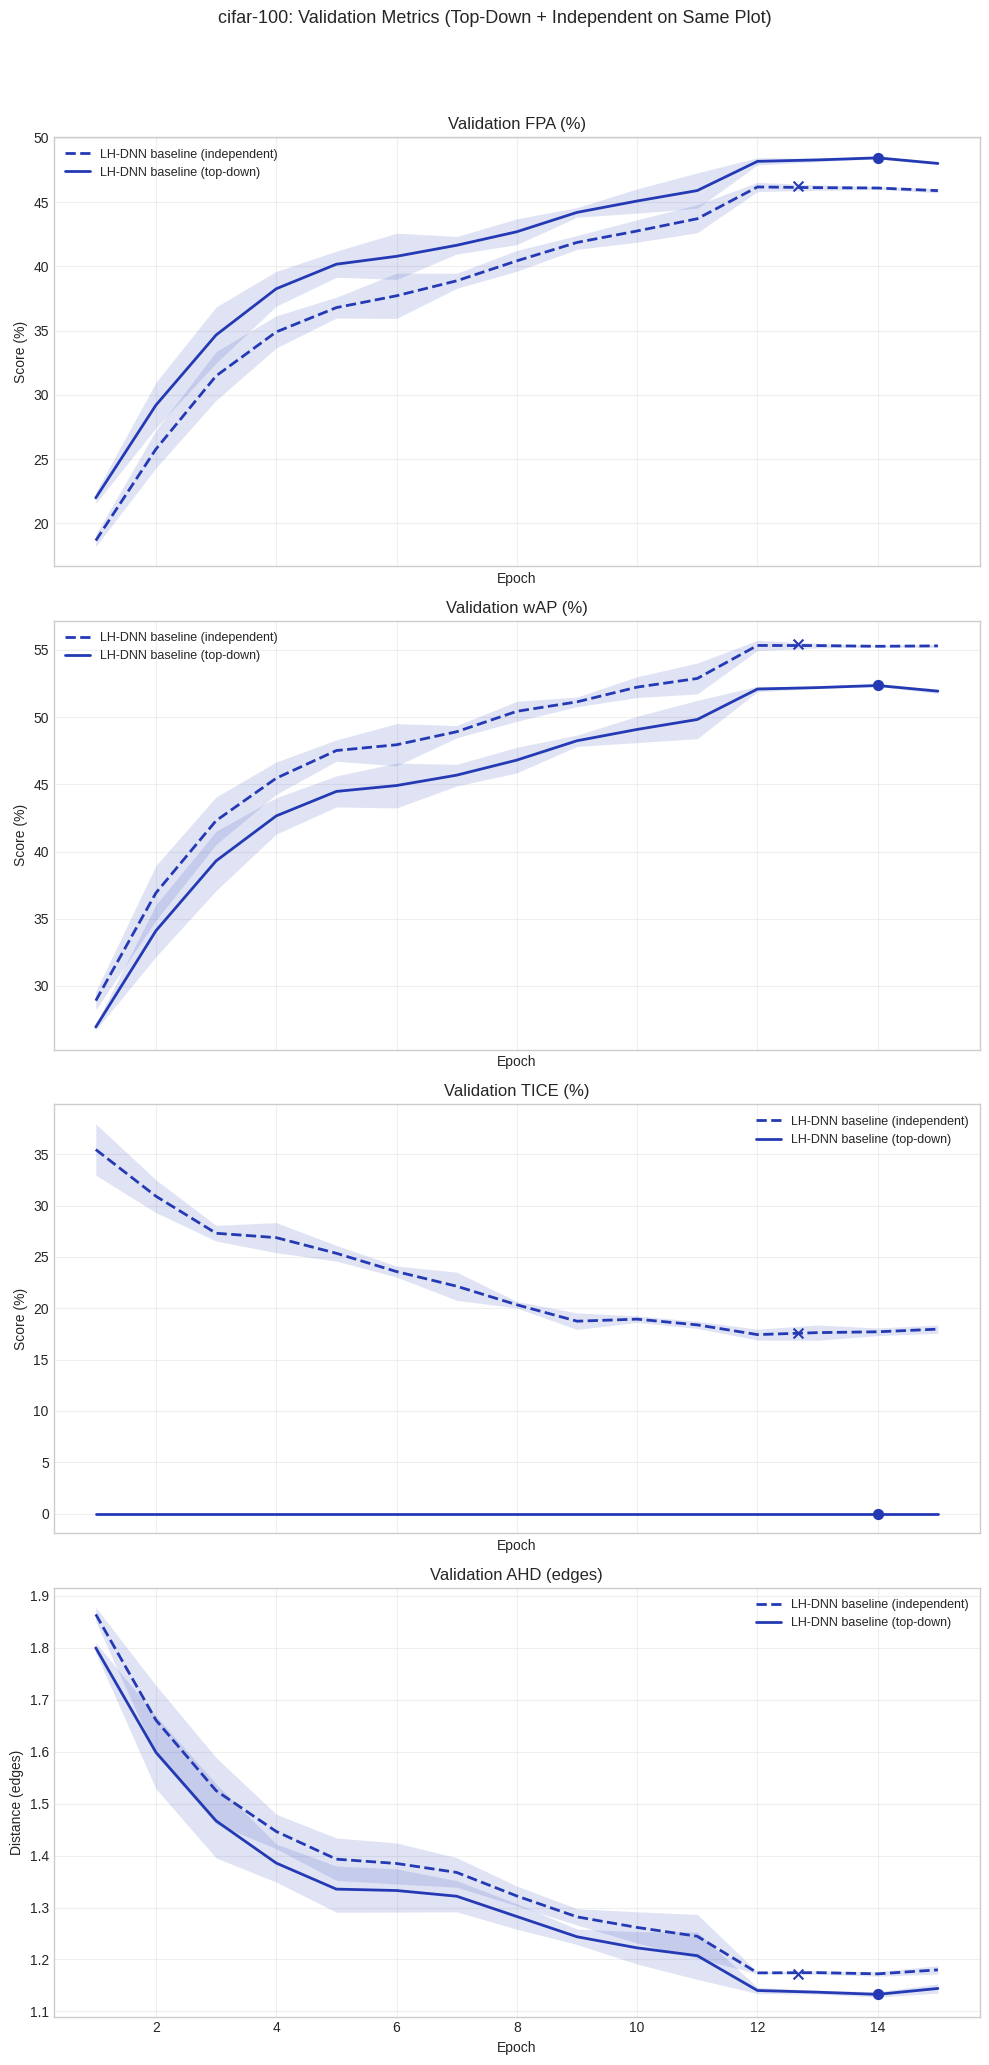

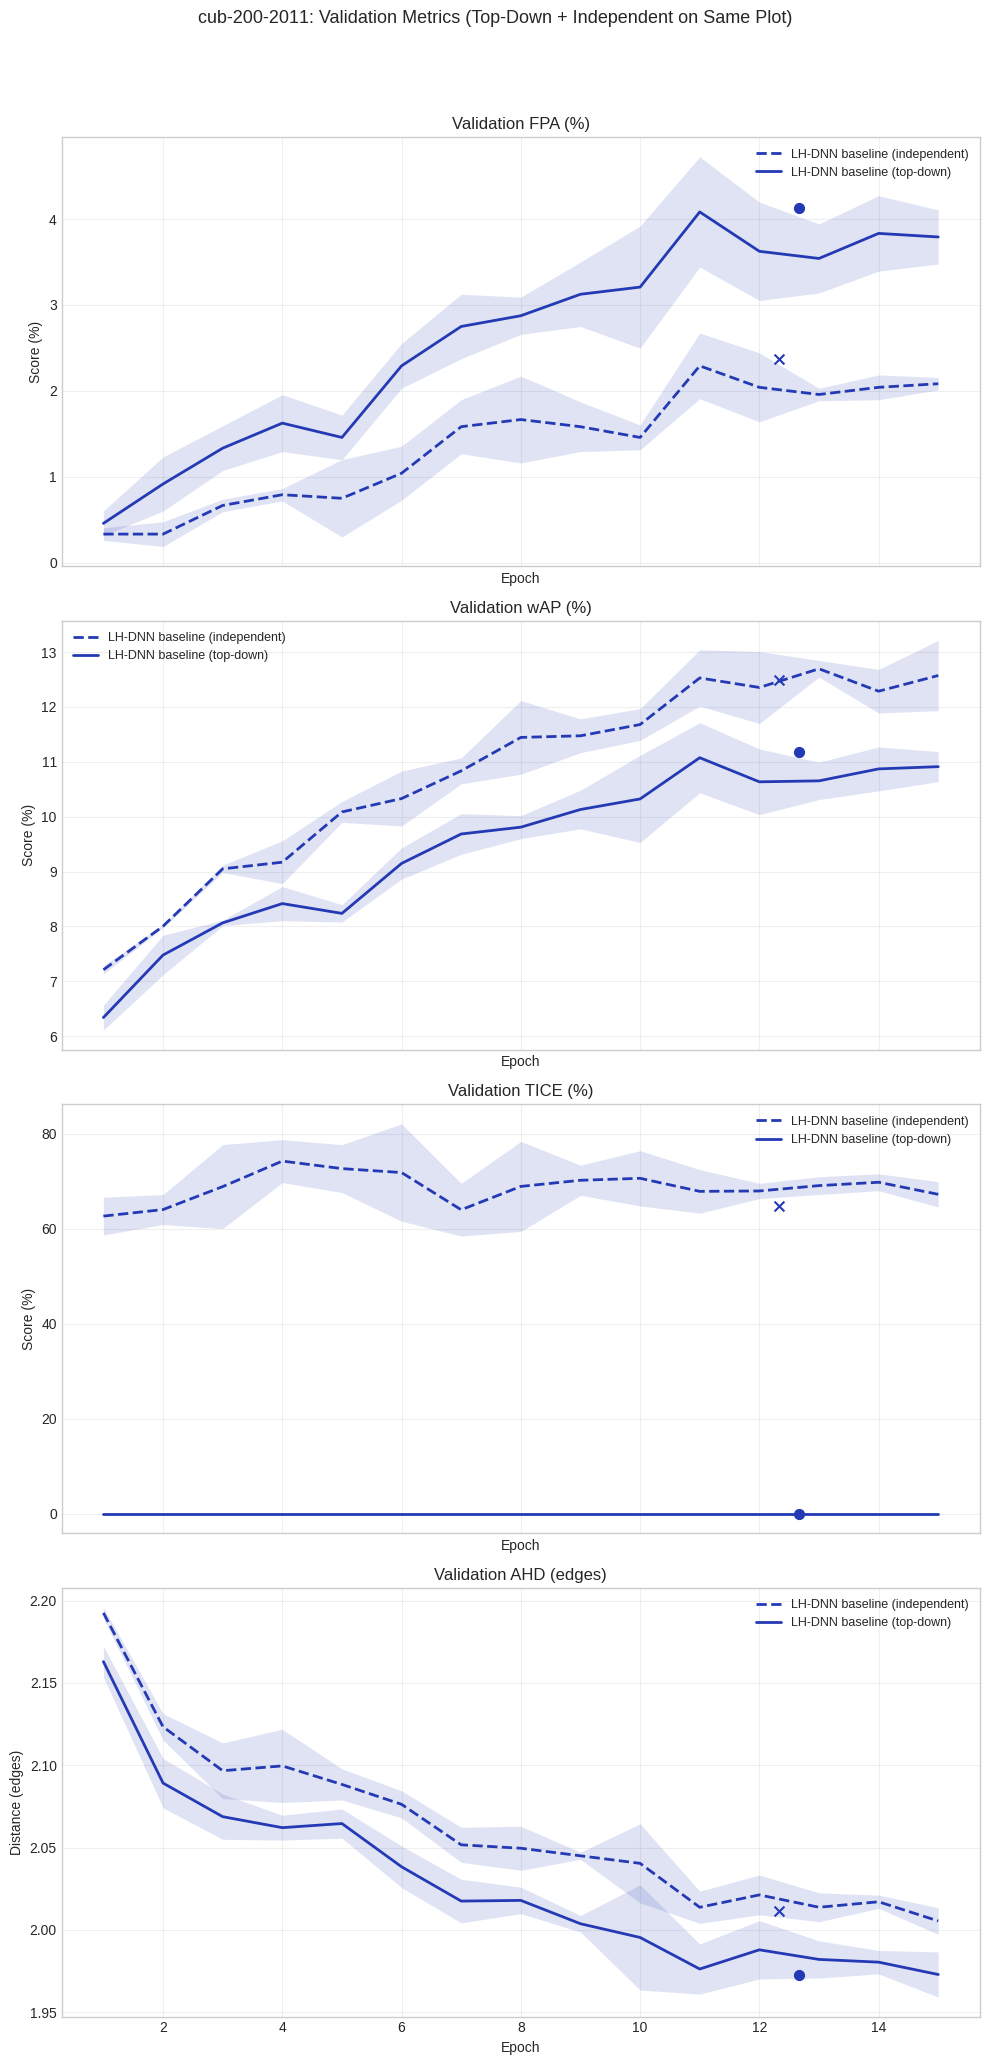

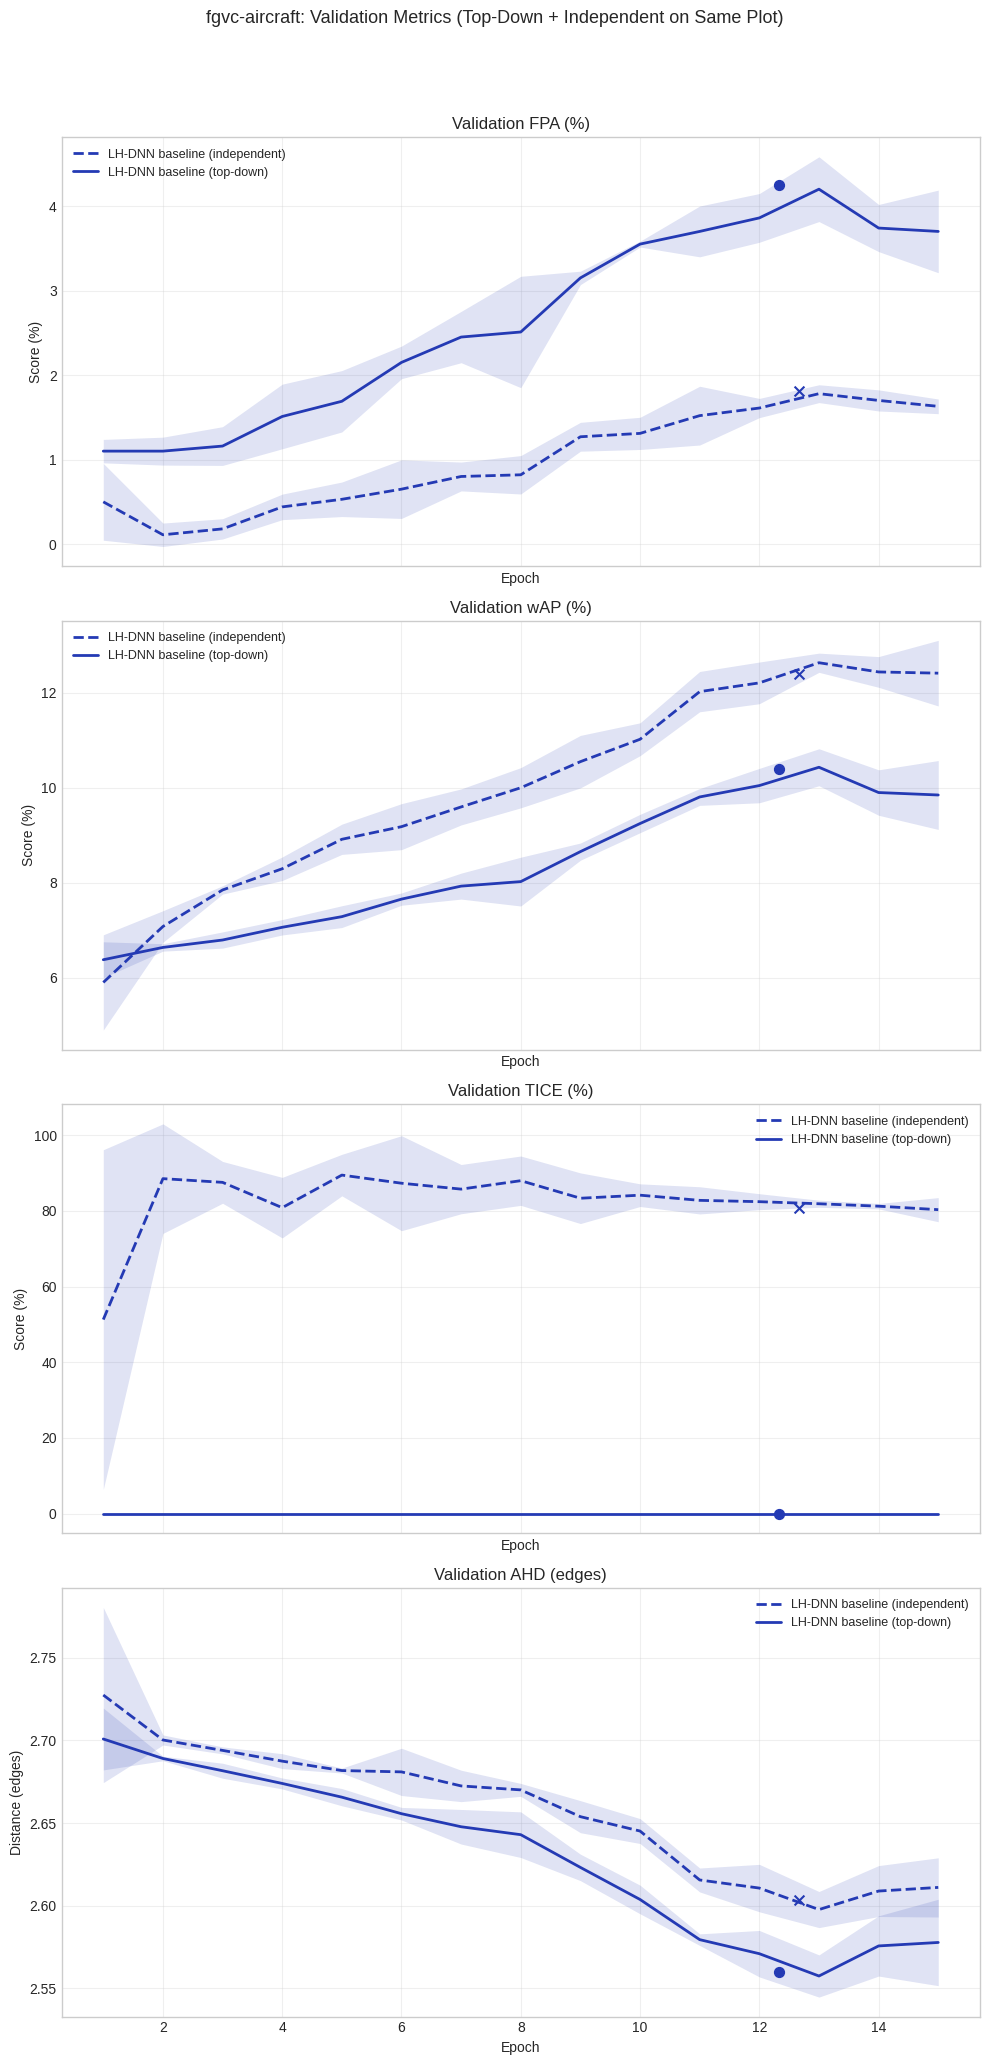

In [13]:
analysis.plot_validation_curves()

Interpretation note:

- FPA and weighted AP are higher-is-better; TICE and AHD are lower-is-better.
- Compare solid and dashed lines of the same color to isolate decoder dependence.
- Compare datasets only with care: CUB and Aircraft are extrapolations not evaluated in the LH-DNN paper.

## LH-DNN Projection Semantics

LH-DNN restricts lower-priority backward directions through its projection blocks while preserving the forward scores. Consequently, forward pre/post logit-delta diagnostics are not evidence of whether the LH-DNN projection is active. Use the model/config identity together with the gradient diagnostics below; do not interpret zero forward logit deltas as an inactive projection.

## Training Loss Comparison

LH-DNN optimizes the unweighted sum of per-level cross-entropies. `total` and `level_ce` therefore coincide, while `loss_level_*` exposes the contribution from each hierarchy level.

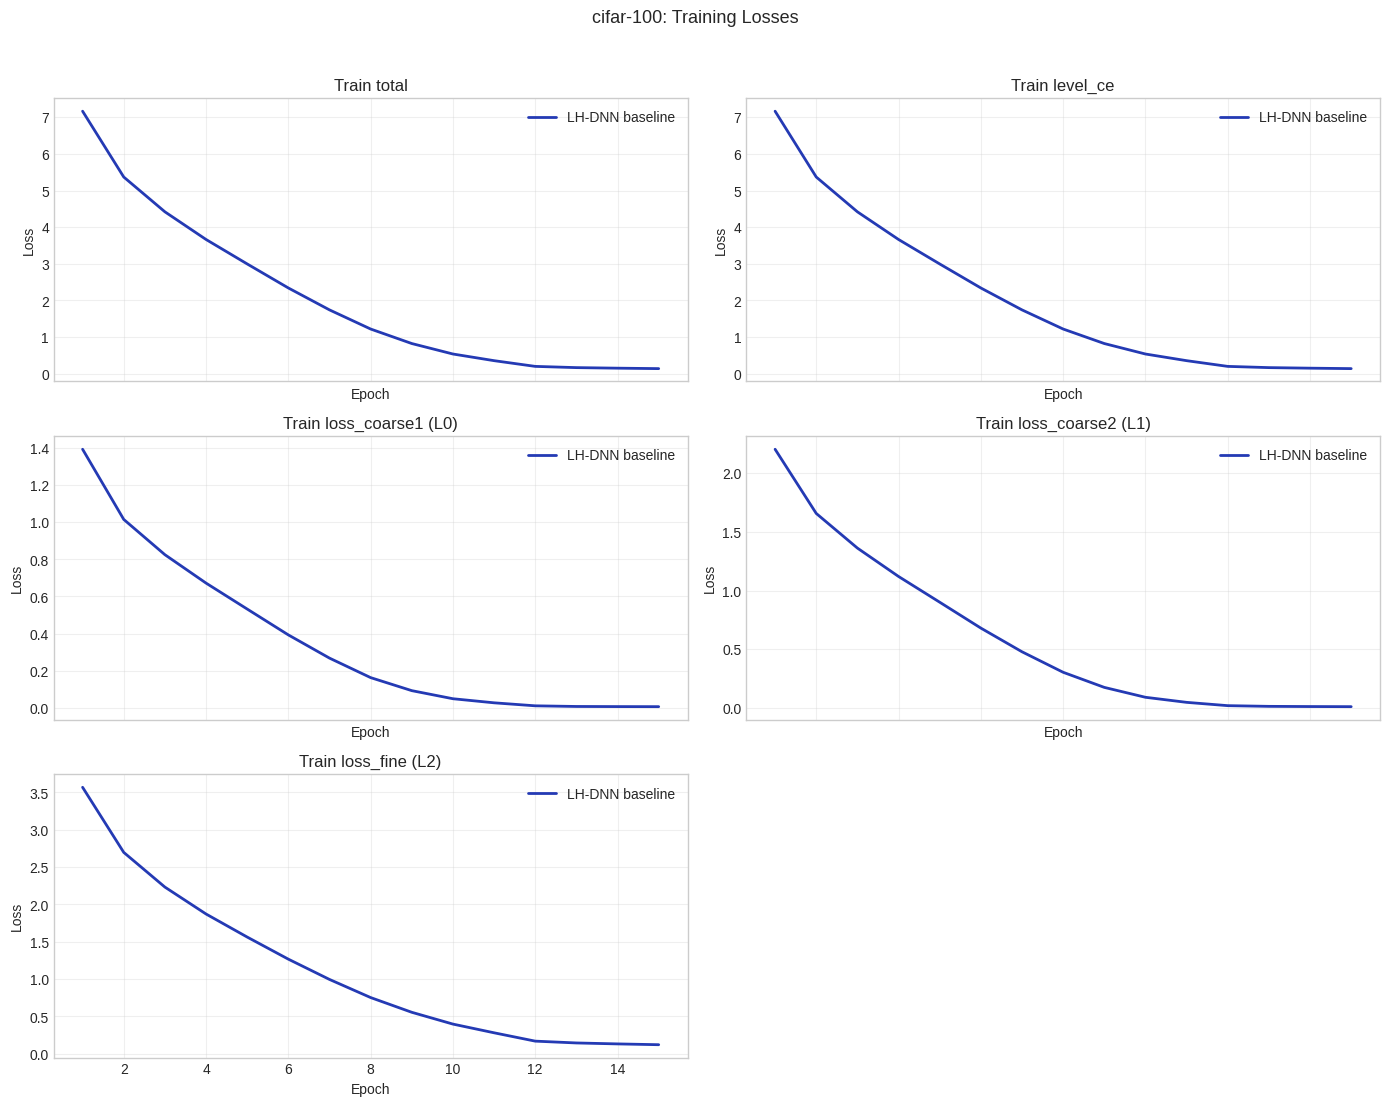

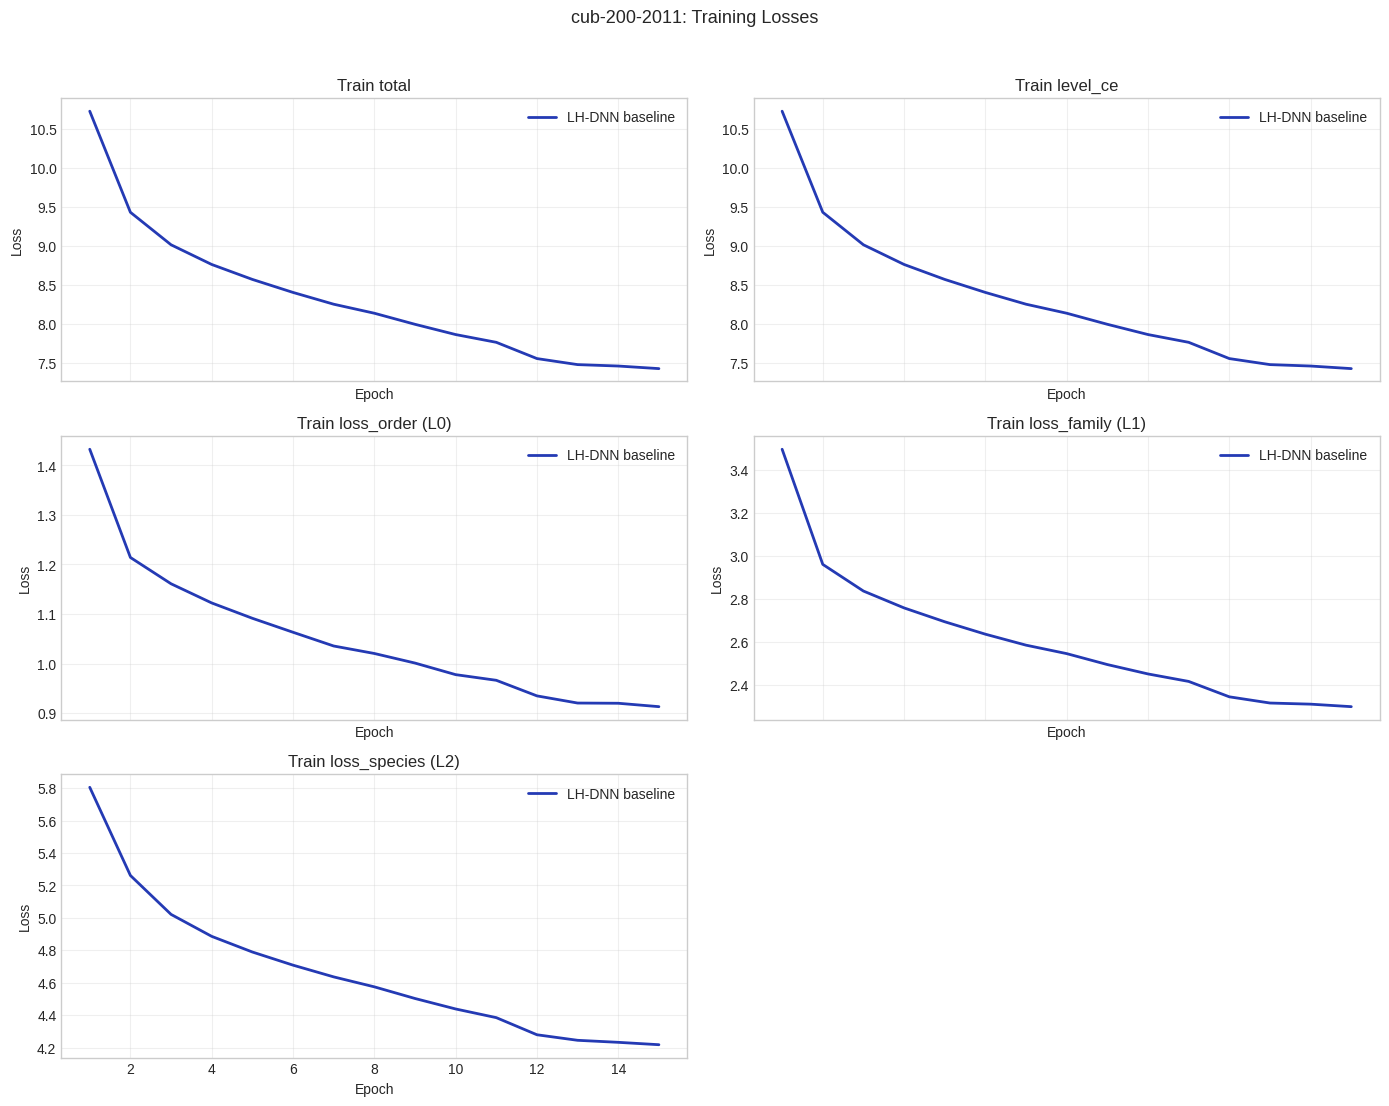

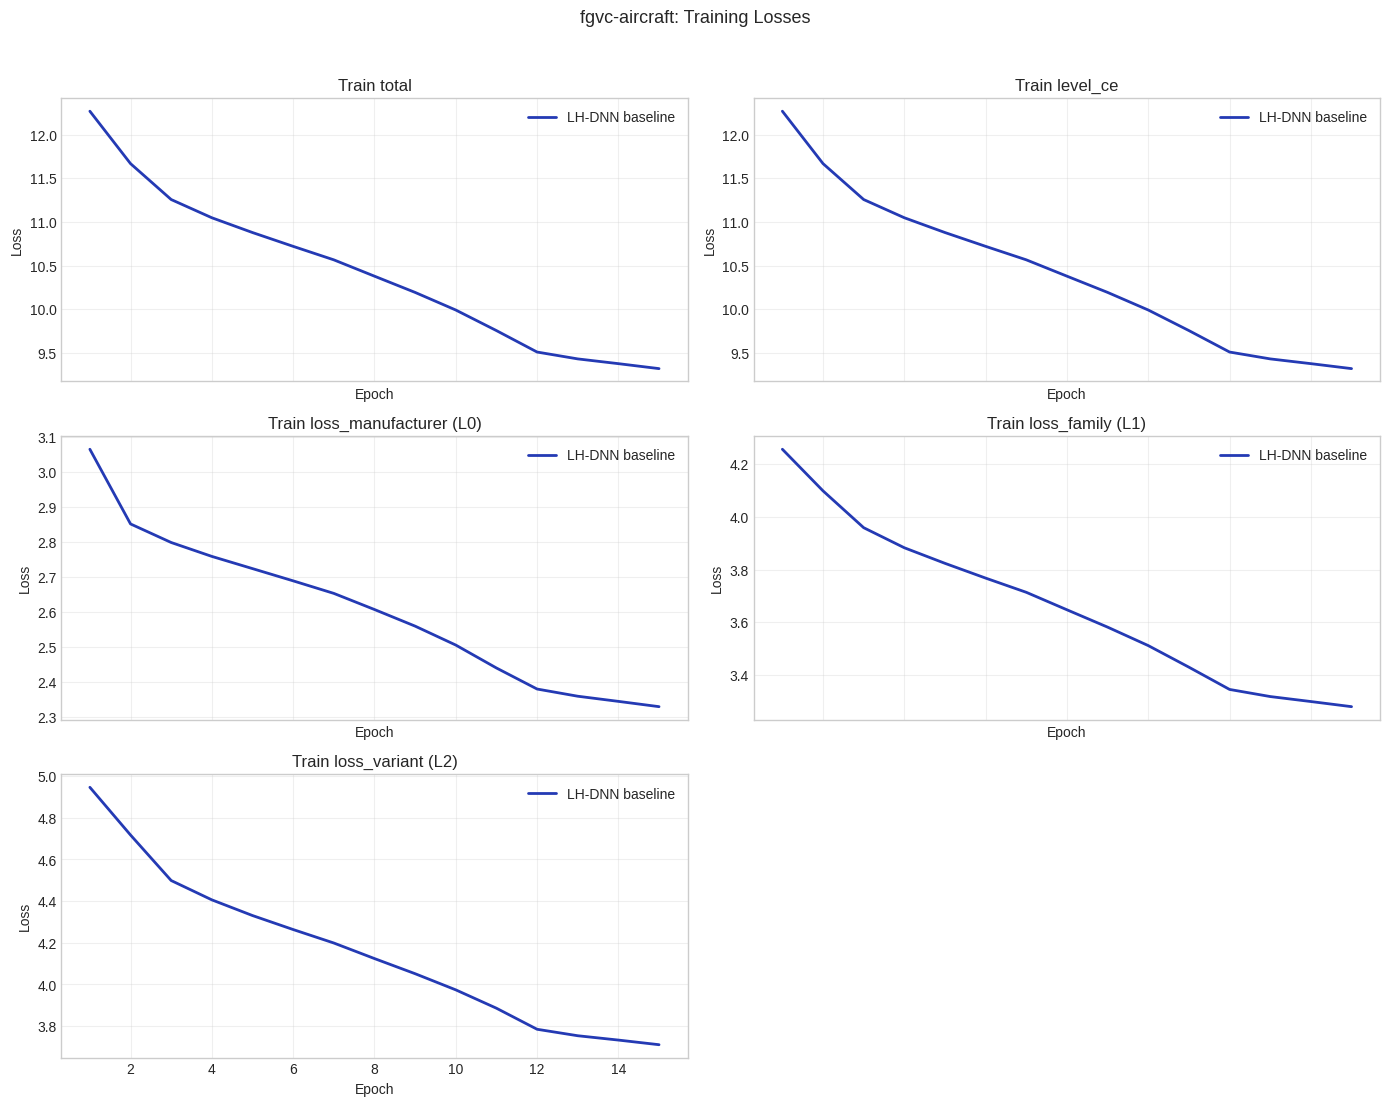

In [14]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'level_ce'])

## Per-Run Per-Level Training Losses

Compare levels within one run before comparing across datasets, since the number of classes and task difficulty differ substantially.

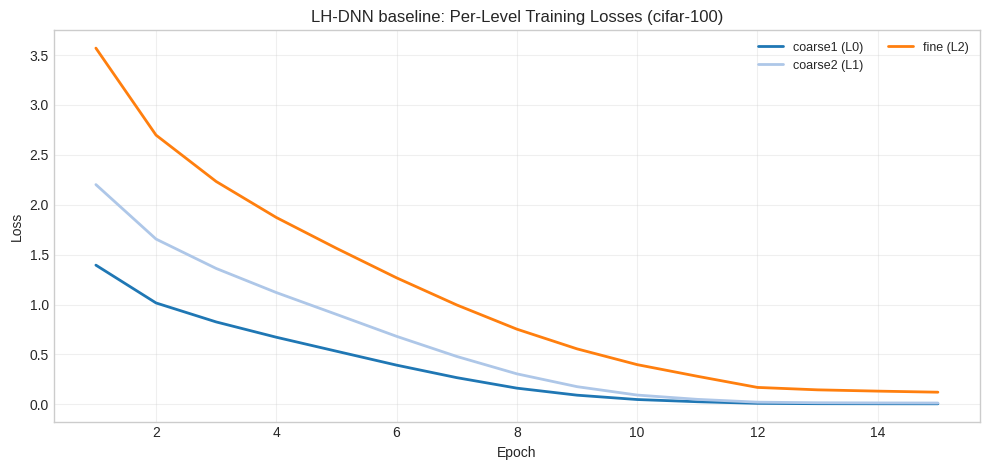

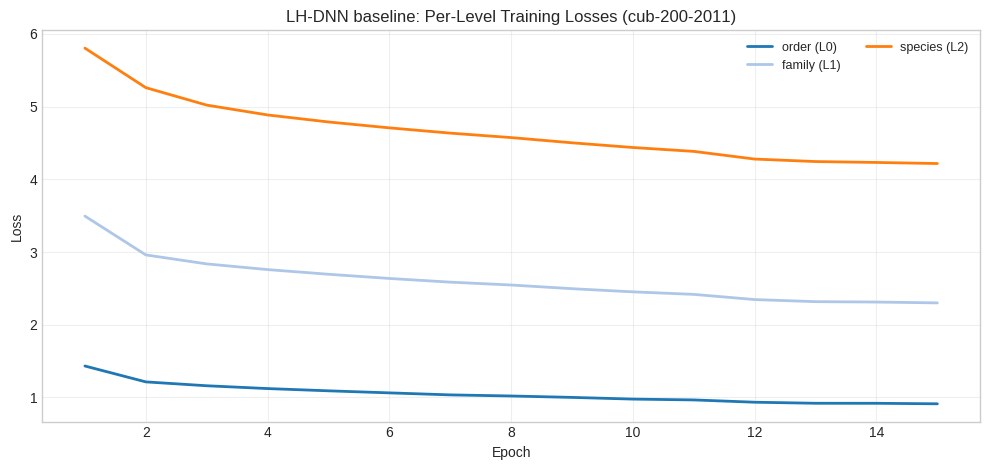

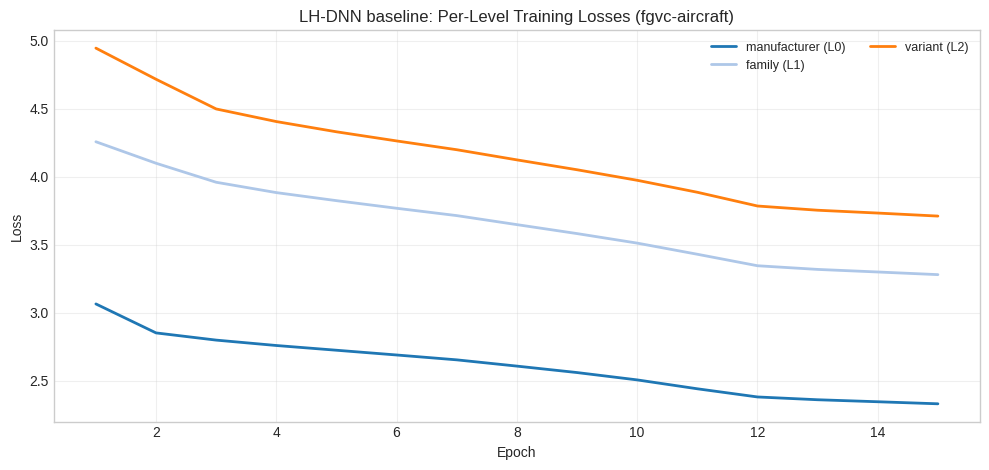

In [15]:
analysis.plot_per_run_per_level_training_losses()

## Gradient Diagnostics (Train)

This section visualizes the shared-trunk gradient, parameter, and level-conflict diagnostics stored in `train_metrics`. LH-DNN's architecture performs its own backward-space restriction; these generic diagnostics describe the resulting shared-parameter behavior and should not be confused with the explicit `train.lexicographic.enabled` optimizer path.

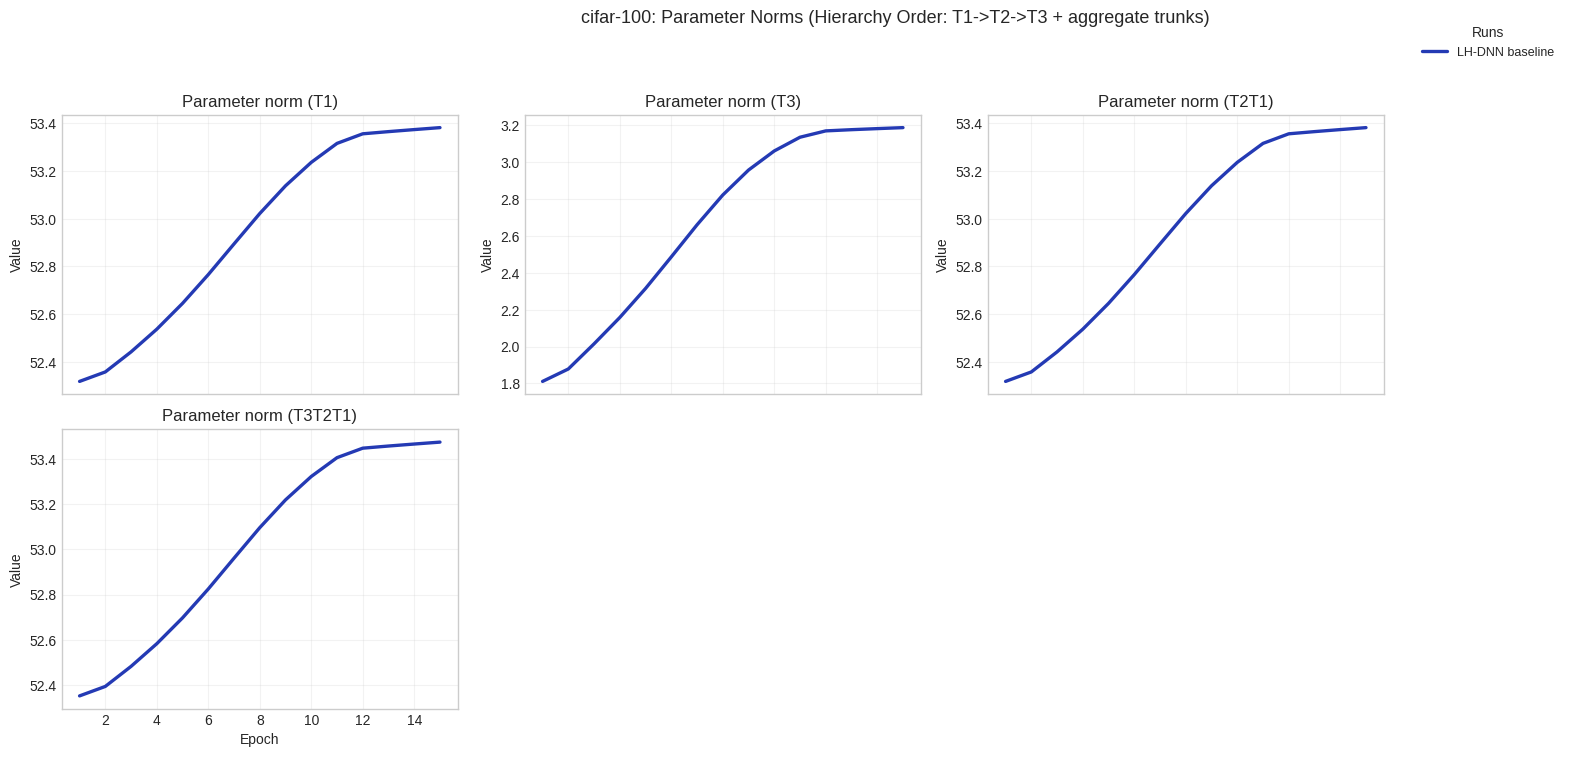

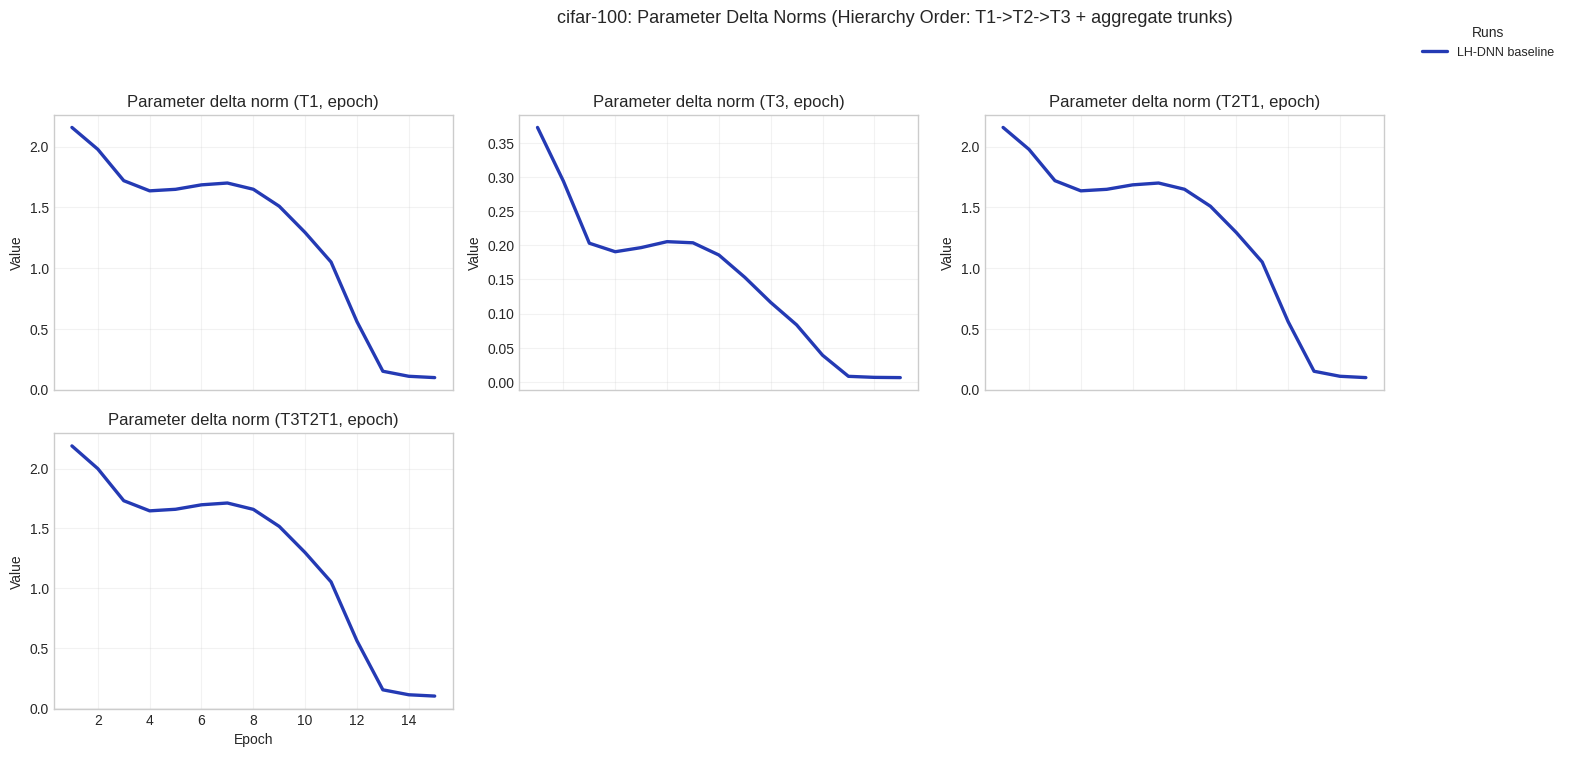

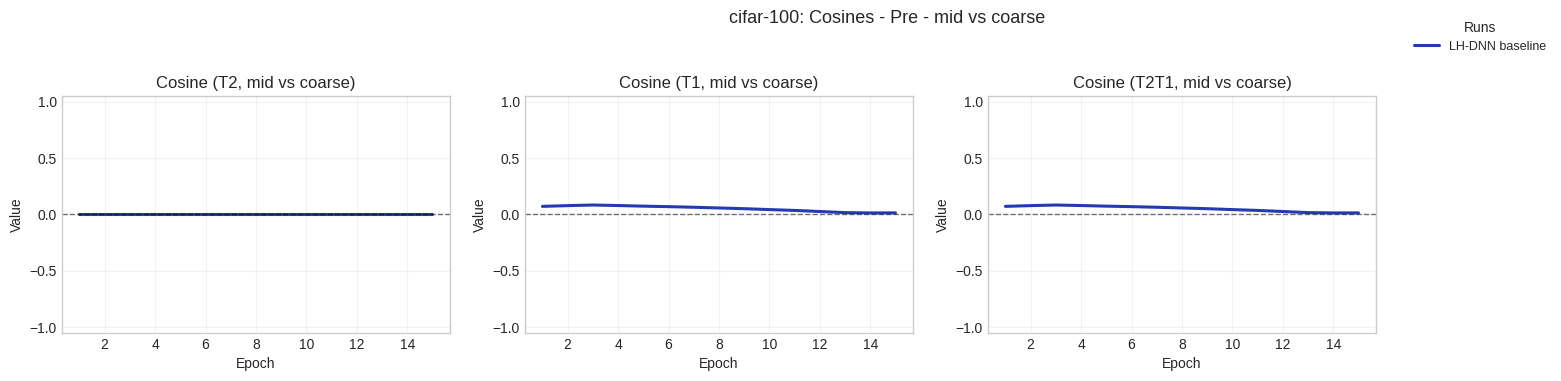

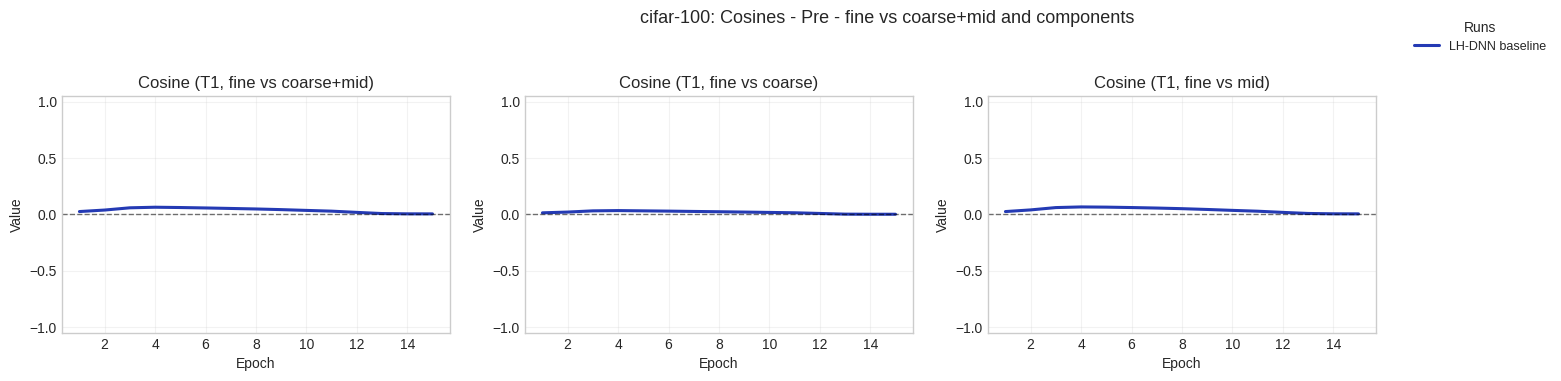

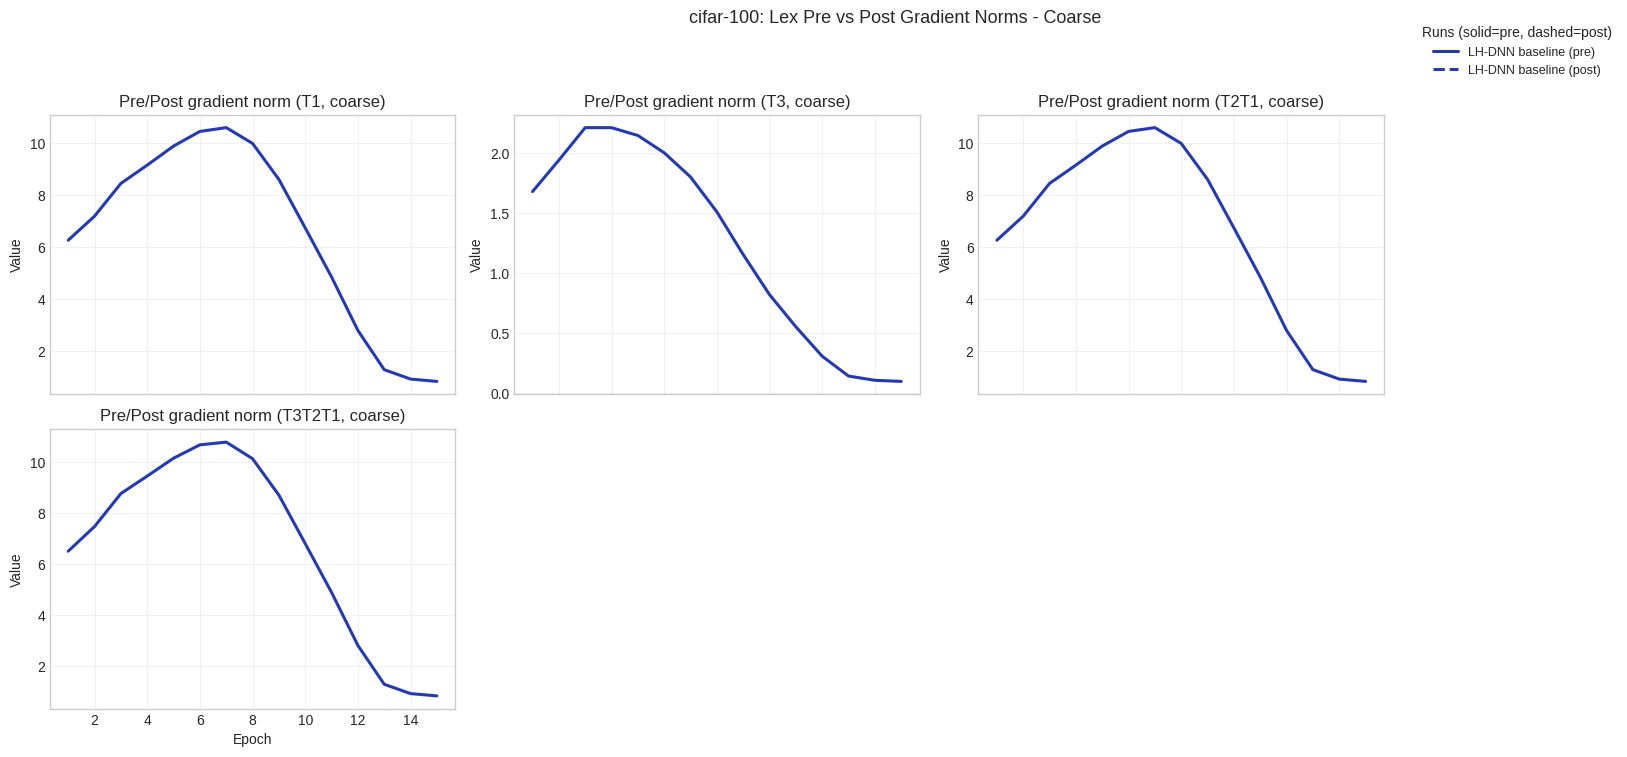

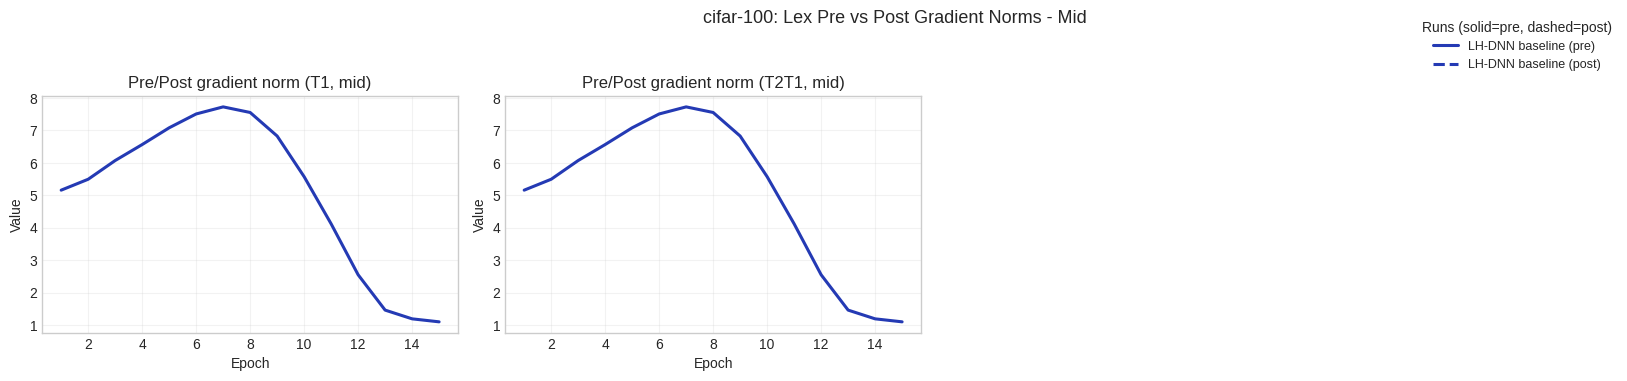

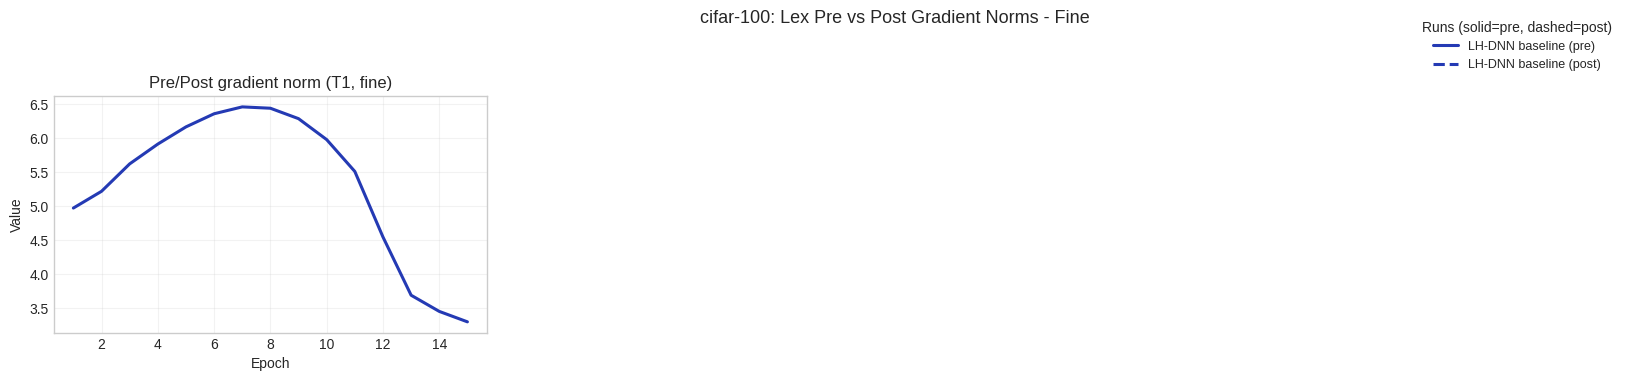

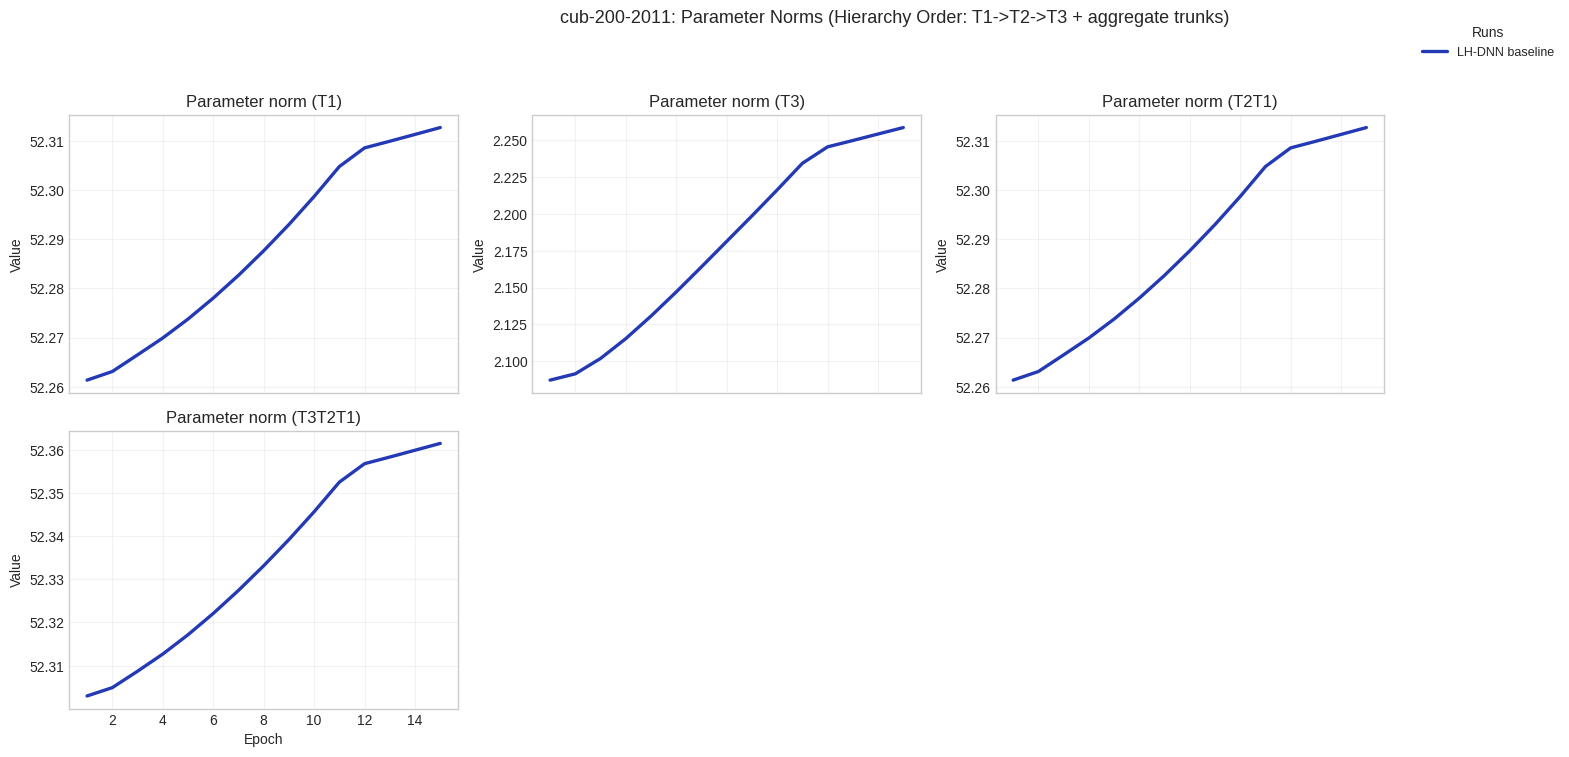

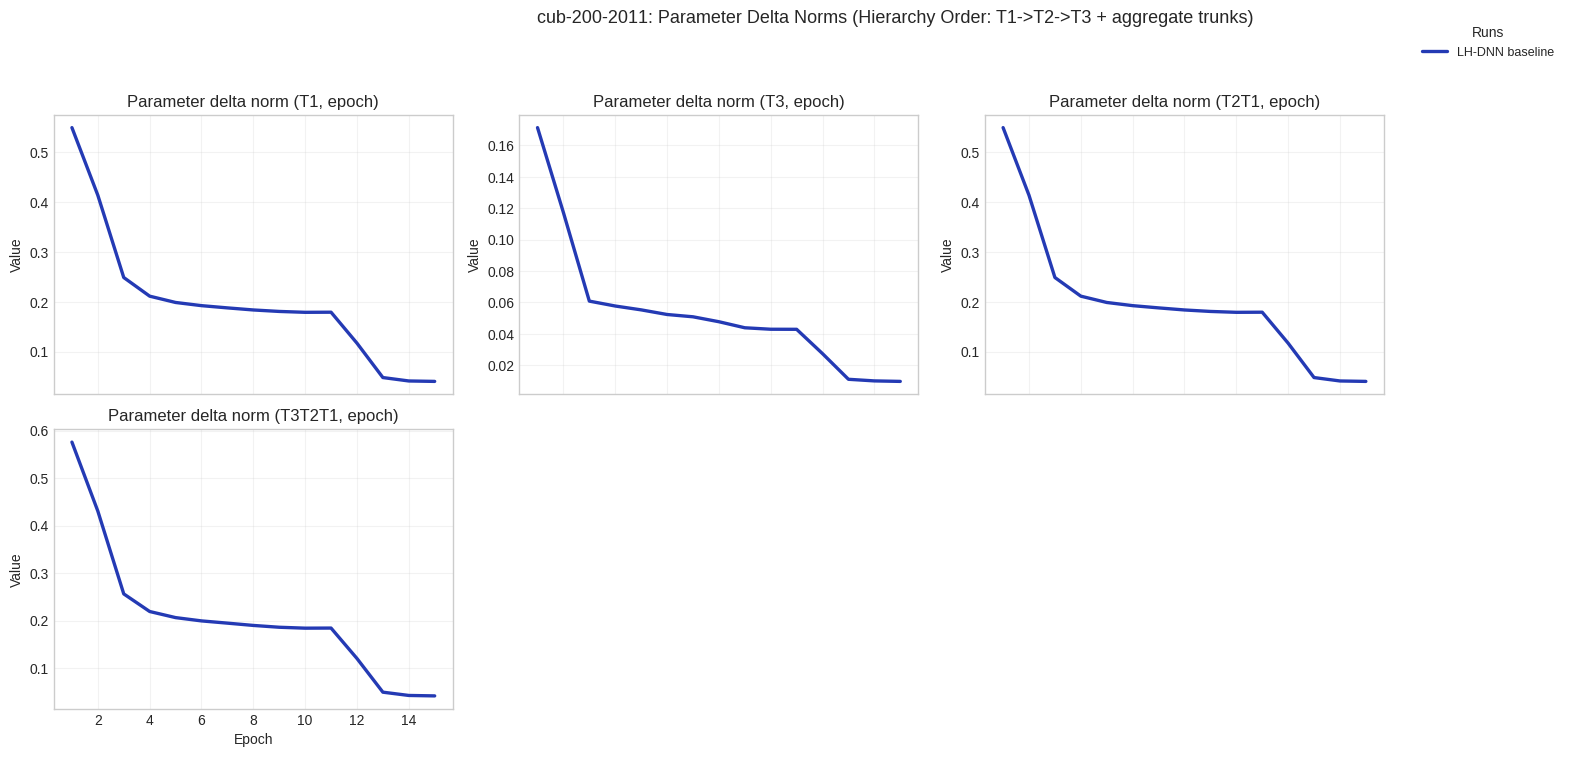

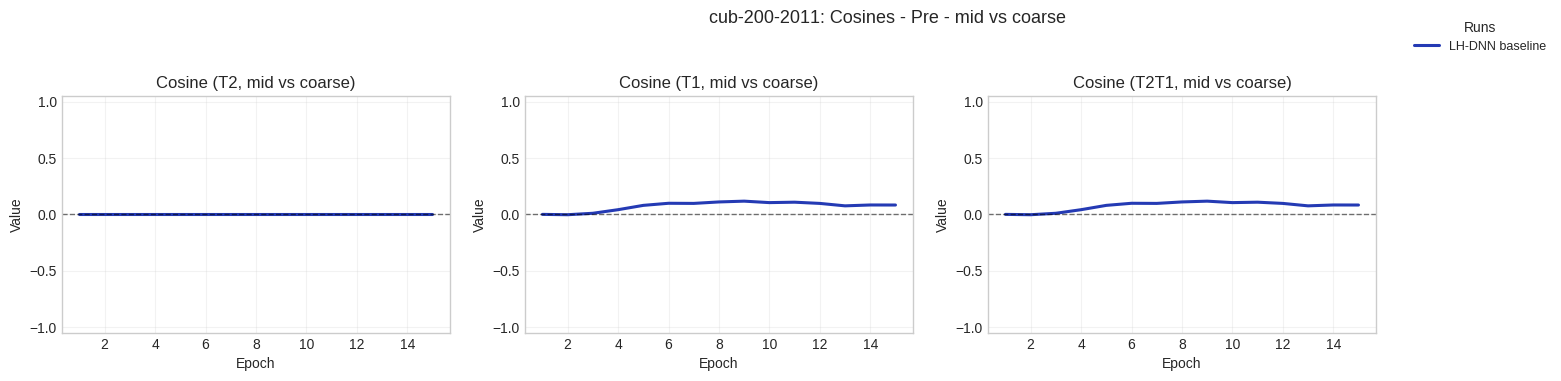

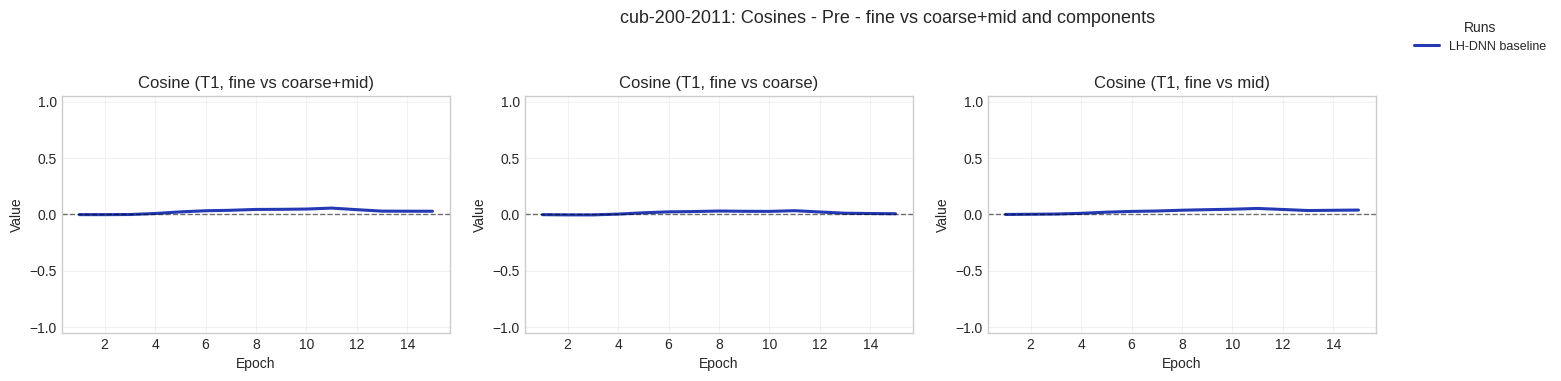

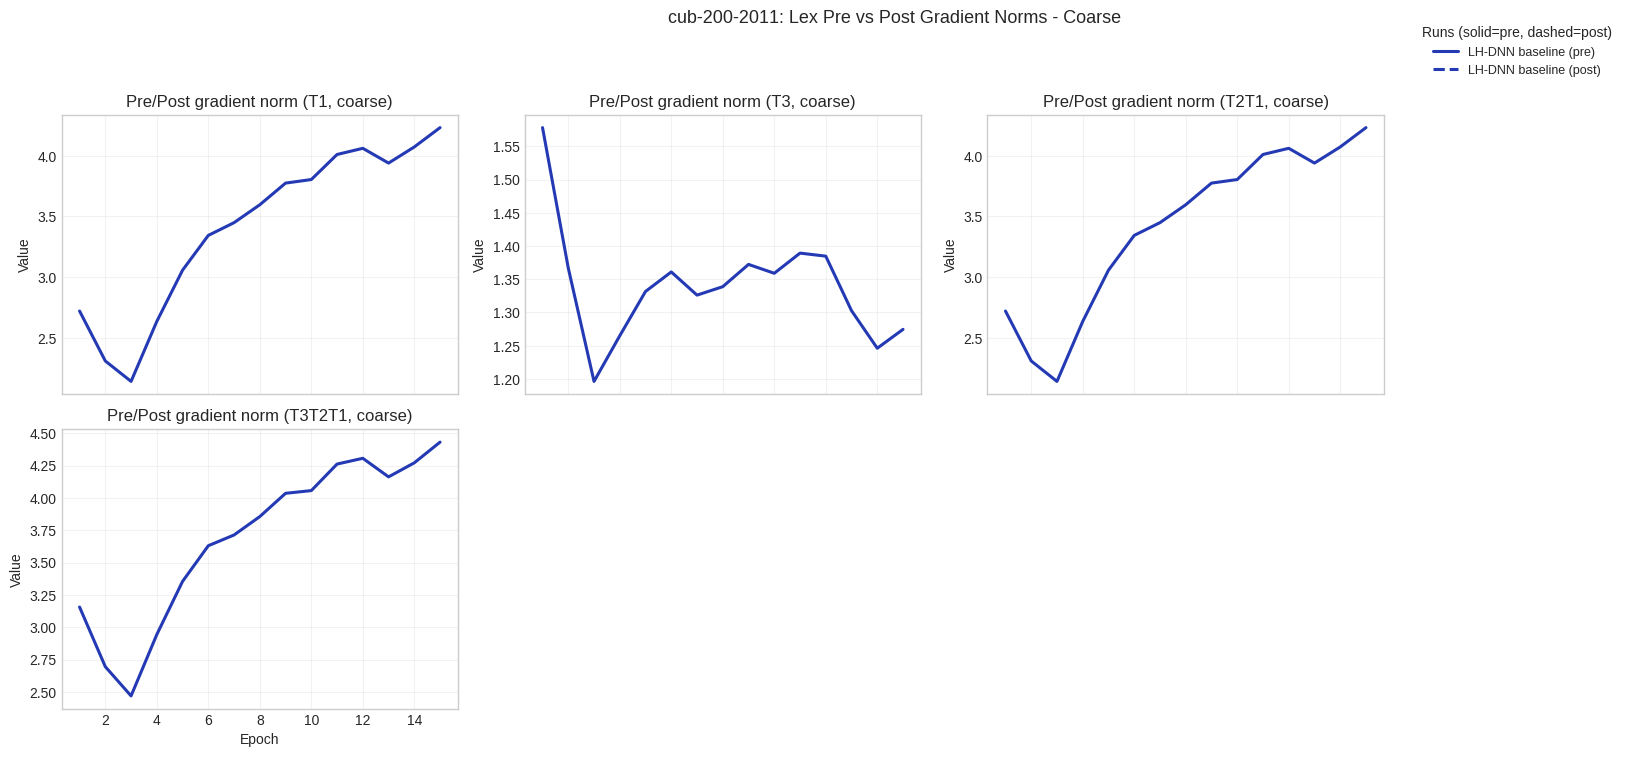

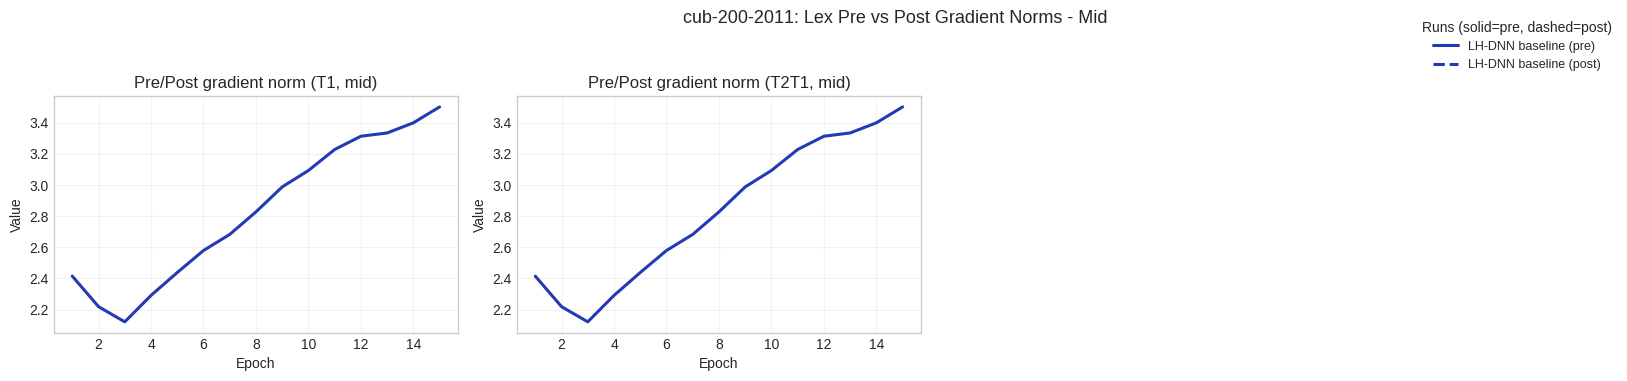

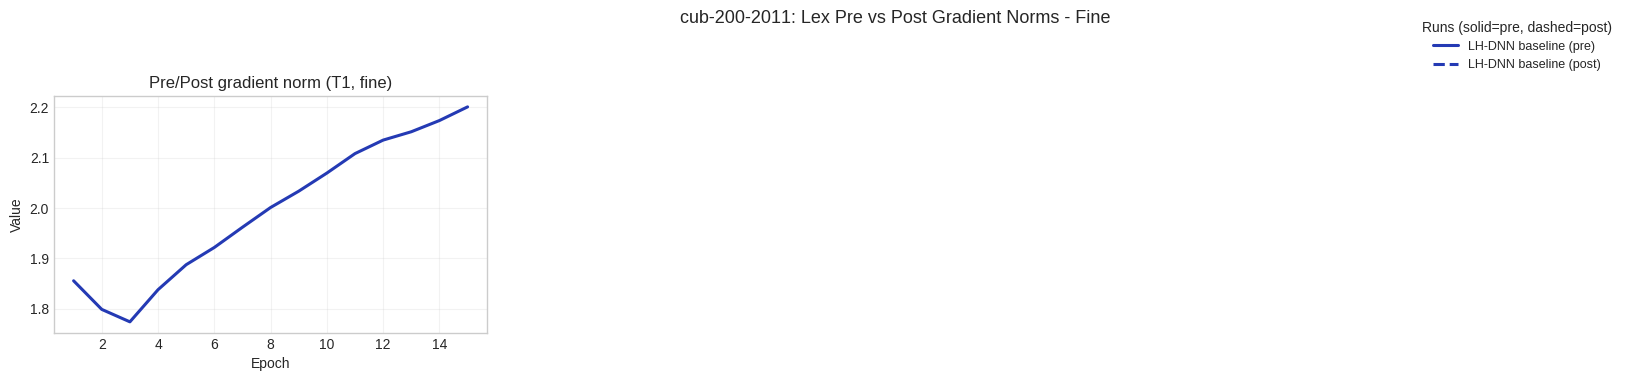

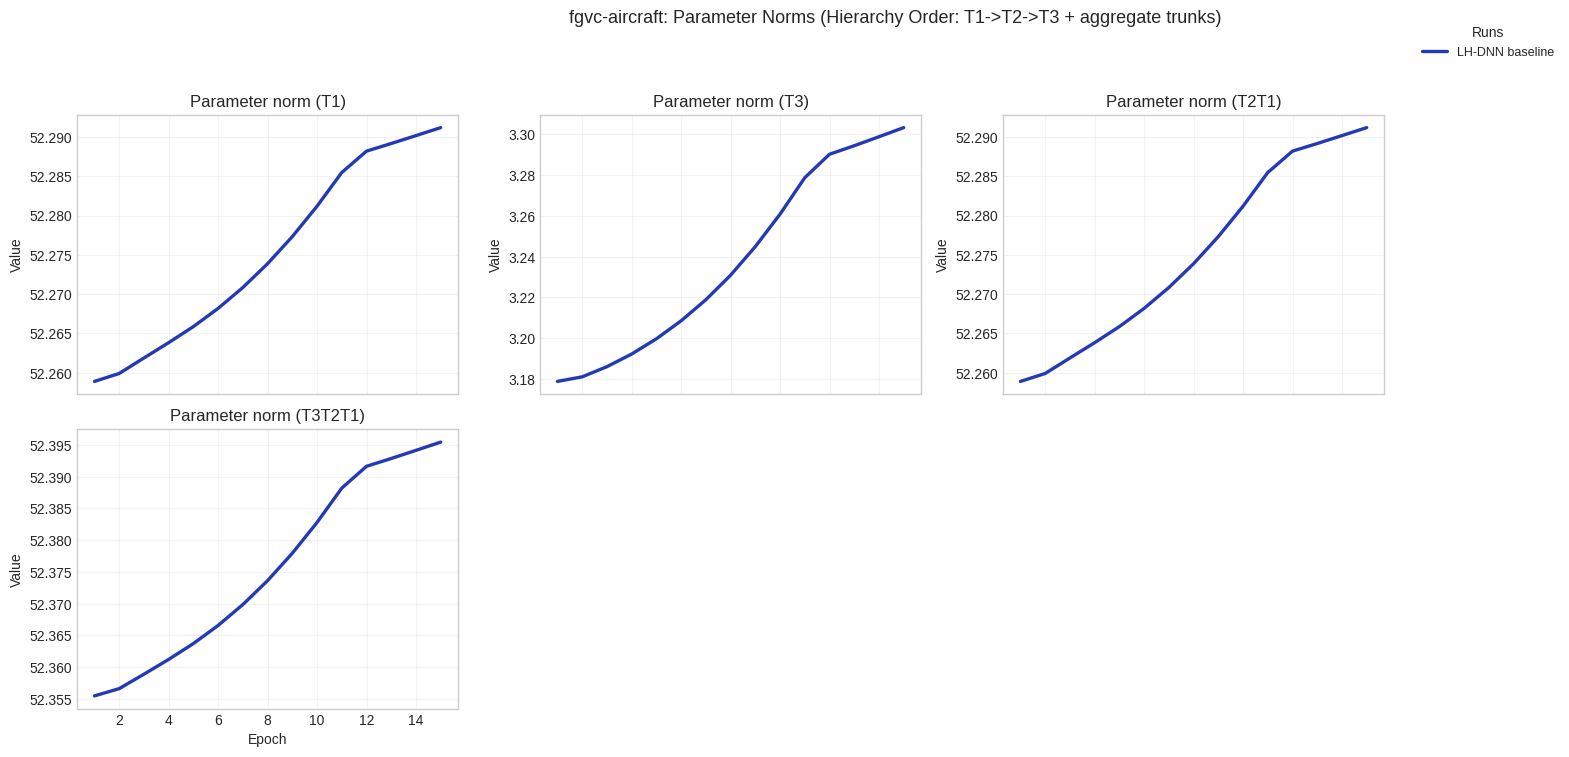

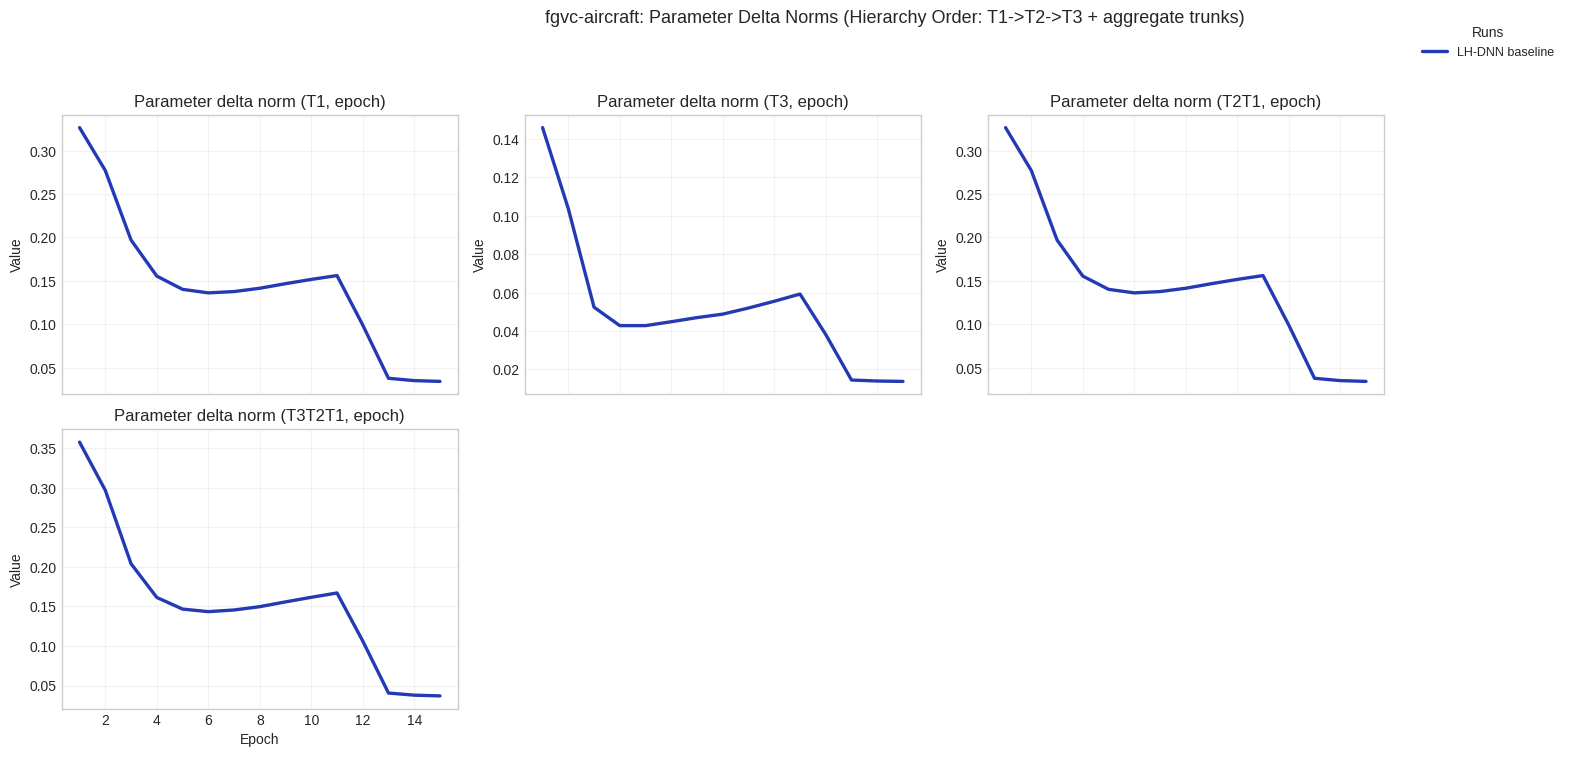

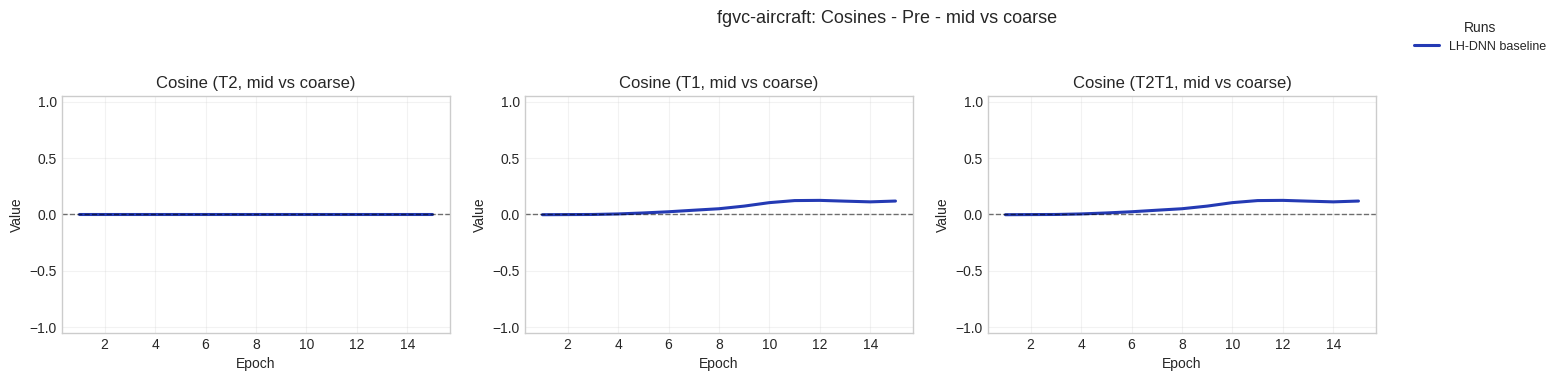

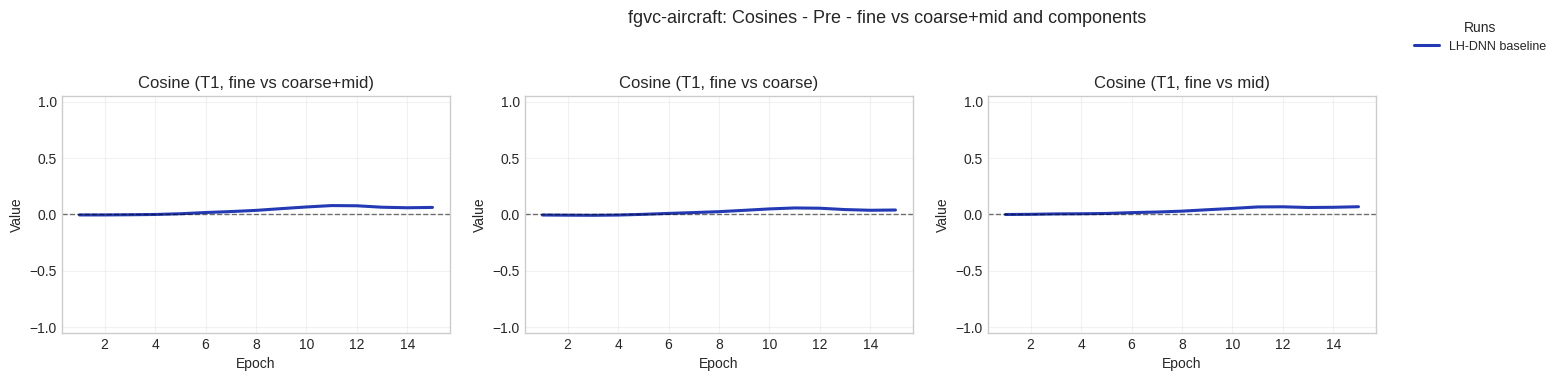

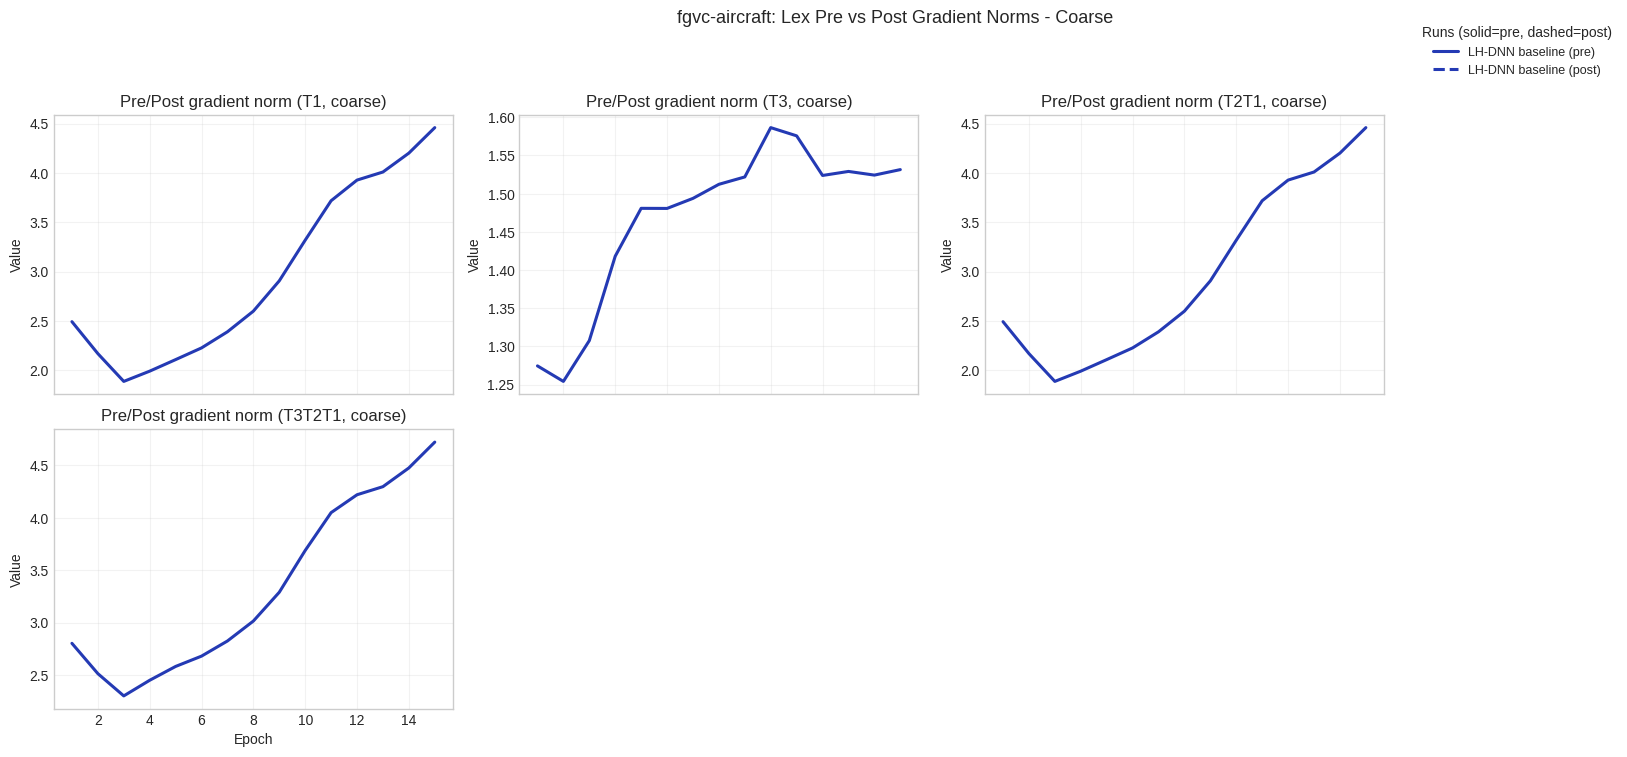

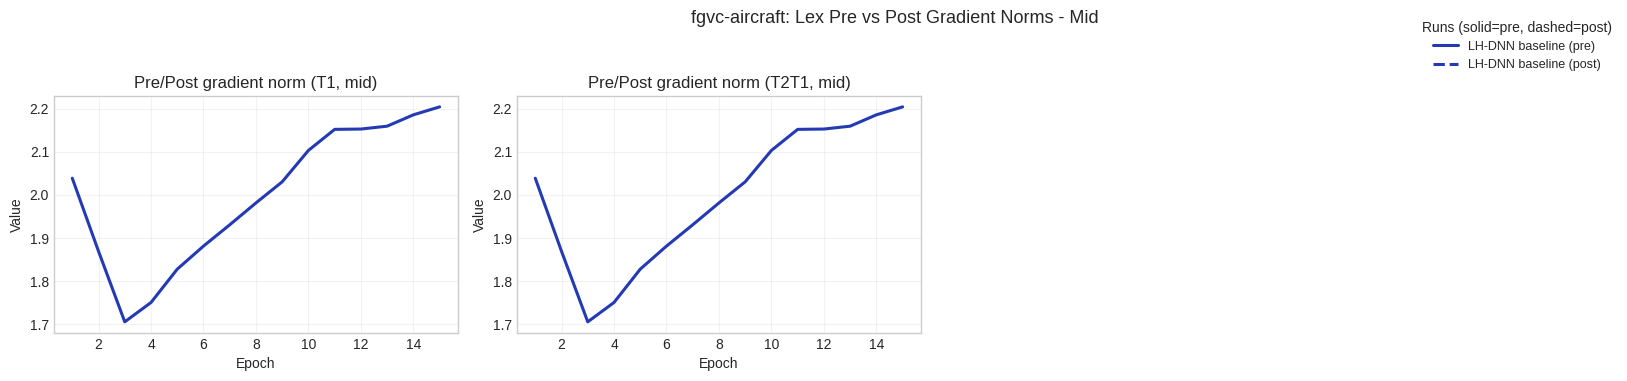

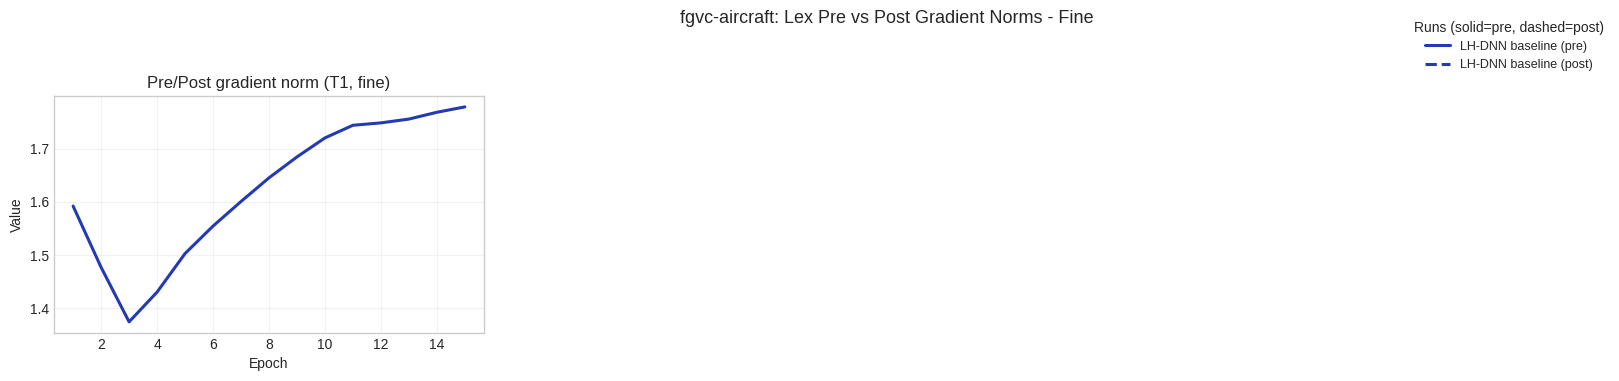

In [16]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)

Interpretation note:

- Large norm spikes indicate unstable update pressure on the measured subset or level path.
- Cosines near +1 indicate aligned objectives, near -1 indicate conflict, and near 0 indicate near-orthogonal gradients.
- Absence of generic `post_*` metrics is expected because LH-DNN is not using the separate explicit gradient-space lexicographic optimizer.

## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays top-down and independent decoding. Match line style when comparing runs and match color when measuring decoder dependence.

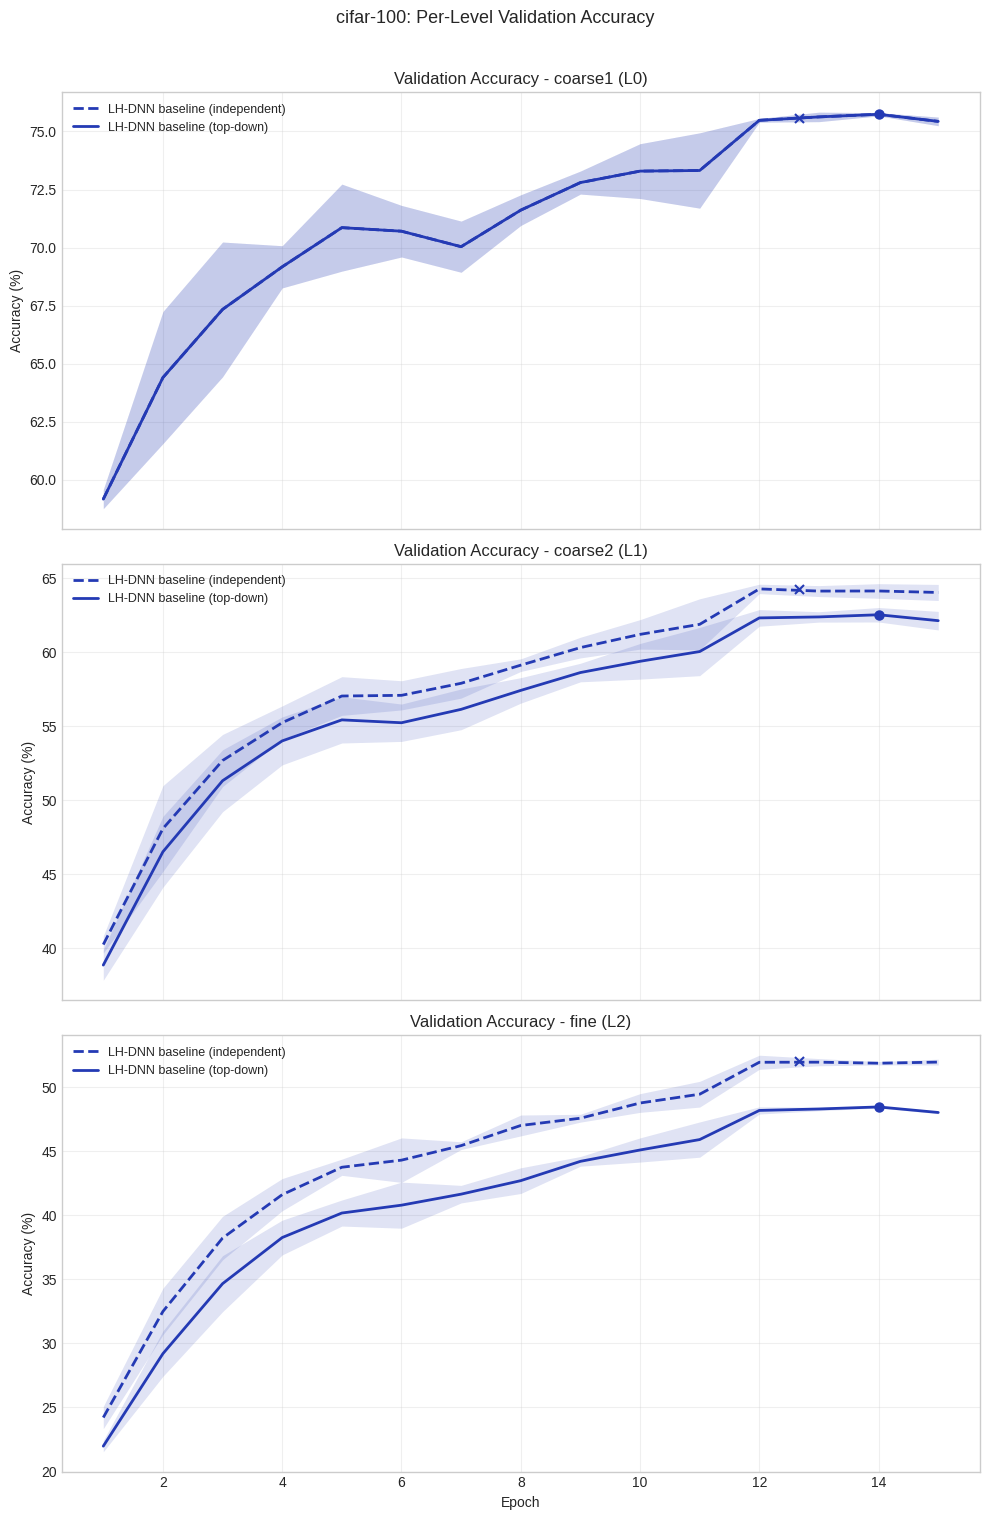

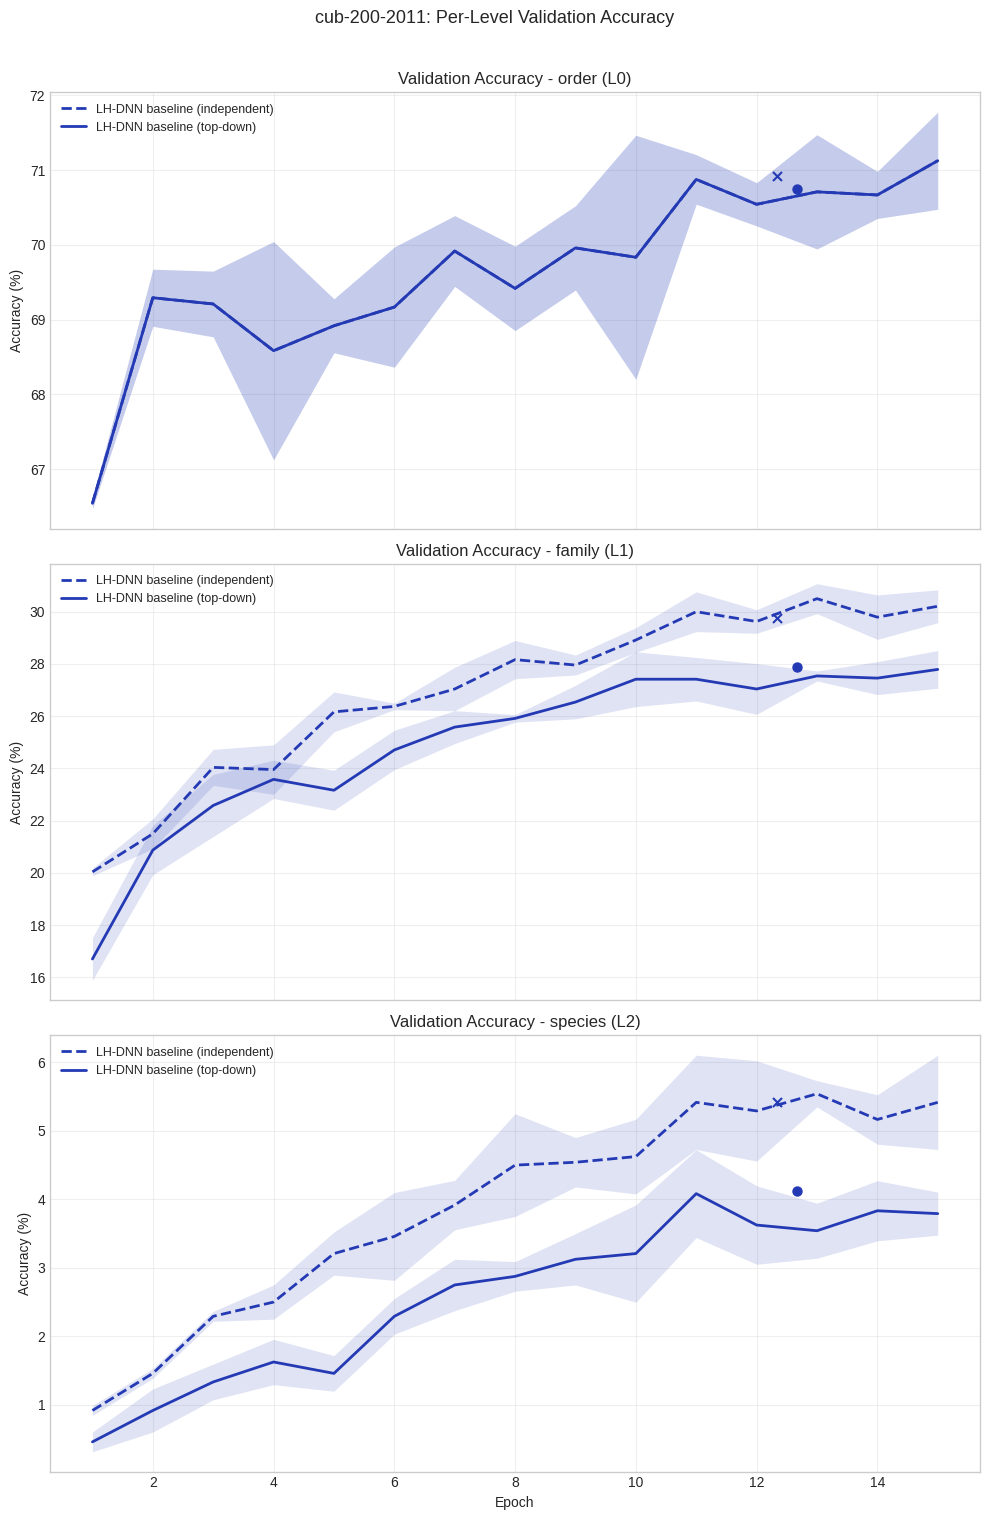

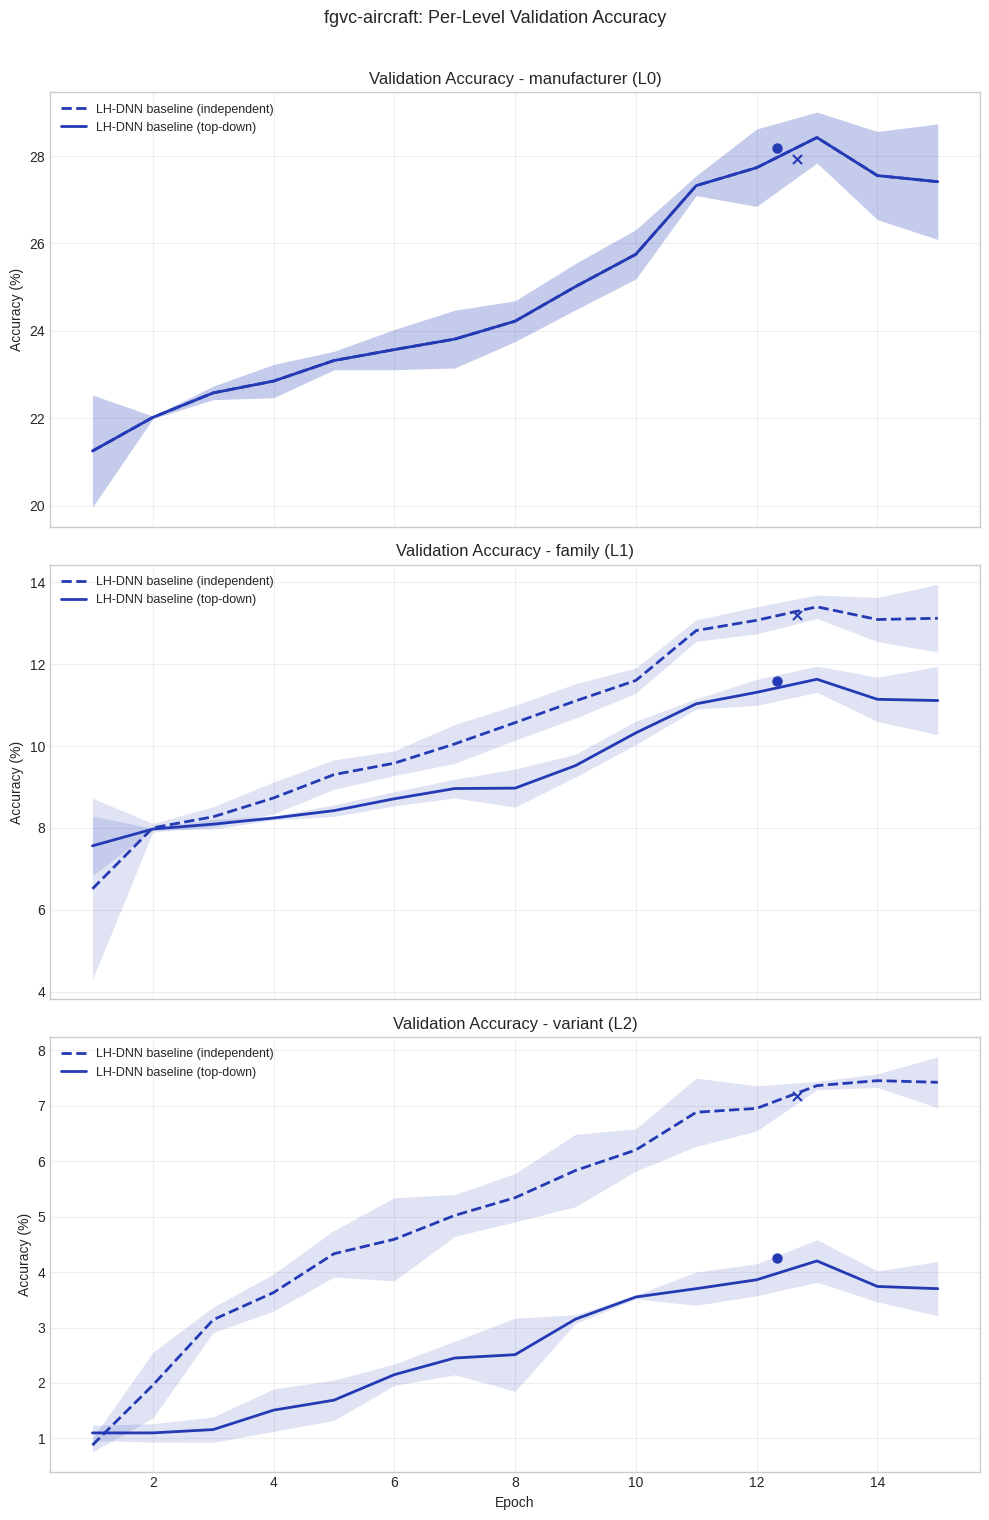

In [17]:
analysis.plot_per_level_validation_accuracy()

## Final Test Comparison Table

For every dataset, top-down metrics use the top-down-selected checkpoint and independent metrics use the independent-selected checkpoint. The table includes FPA, weighted AP, TICE, AHD, and every available per-level accuracy in both decoding modes. With multiple seeds, values are reported as mean and sample standard deviation.

In [18]:
analysis.show_final_test_tables(allow_single_run=True)

### Dataset: `cifar-100`
Baseline run: **LH-DNN baseline**

| Metric | LH-DNN baseline (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 14.0 ± 0.0/12.7 ± 1.2 |
| FPA independent ↑ | **46.14% ± 0.60%** |
| FPA top-down ↑ | **48.20% ± 0.32%** |
| wAP independent ↑ | **55.00% ± 0.48%** |
| wAP top-down ↑ | **51.97% ± 0.32%** |
| TICE independent ↓ | **17.51% ± 0.47%** |
| TICE top-down ↓ | **0.00% ± 0.00%** |
| AHD independent ↓ | **1.189 ± 0.016** |
| AHD top-down ↓ | **1.154 ± 0.009** |
| Acc independent coarse1 (L0) ↑ | **74.63% ± 0.47%** |
| Acc top-down coarse1 (L0) ↑ | **74.55% ± 0.27%** |
| Acc independent coarse2 (L1) ↑ | **63.32% ± 0.52%** |
| Acc top-down coarse2 (L1) ↑ | **61.81% ± 0.41%** |
| Acc independent fine (L2) ↑ | **51.76% ± 0.50%** |
| Acc top-down fine (L2) ↑ | **48.20% ± 0.32%** |

### Dataset: `cub-200-2011`
Baseline run: **LH-DNN baseline**

| Metric | LH-DNN baseline (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 12.7 ± 2.1/12.3 ± 2.3 |
| FPA independent ↑ | **2.33% ± 0.23%** |
| FPA top-down ↑ | **3.66% ± 0.31%** |
| wAP independent ↑ | **12.64% ± 0.61%** |
| wAP top-down ↑ | **10.99% ± 0.24%** |
| TICE independent ↓ | **63.05% ± 1.97%** |
| TICE top-down ↓ | **0.00% ± 0.00%** |
| AHD independent ↓ | **1.996 ± 0.015** |
| AHD top-down ↓ | **1.960 ± 0.001** |
| Acc independent order (L0) ↑ | **71.30% ± 0.54%** |
| Acc top-down order (L0) ↑ | **71.44% ± 0.30%** |
| Acc independent family (L1) ↑ | **30.62% ± 1.09%** |
| Acc top-down family (L1) ↑ | **28.87% ± 0.13%** |
| Acc independent species (L2) ↑ | **5.41% ± 0.55%** |
| Acc top-down species (L2) ↑ | **3.66% ± 0.31%** |

### Dataset: `fgvc-aircraft`
Baseline run: **LH-DNN baseline**

| Metric | LH-DNN baseline (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 12.3 ± 1.2/12.7 ± 1.5 |
| FPA independent ↑ | **1.96% ± 0.23%** |
| FPA top-down ↑ | **3.85% ± 0.38%** |
| wAP independent ↑ | **12.26% ± 0.20%** |
| wAP top-down ↑ | **10.02% ± 0.44%** |
| TICE independent ↓ | **80.71% ± 1.31%** |
| TICE top-down ↓ | **0.00% ± 0.00%** |
| AHD independent ↓ | **2.615 ± 0.004** |
| AHD top-down ↓ | **2.576 ± 0.013** |
| Acc independent manufacturer (L0) ↑ | **26.65% ± 0.49%** |
| Acc top-down manufacturer (L0) ↑ | **27.02% ± 0.49%** |
| Acc independent family (L1) ↑ | **13.42% ± 0.17%** |
| Acc top-down family (L1) ↑ | **11.54% ± 0.57%** |
| Acc independent variant (L2) ↑ | **7.13% ± 0.37%** |
| Acc top-down variant (L2) ↑ | **3.85% ± 0.38%** |

Interpretation note:

- Goal arrows identify metric direction: ↑ is higher-is-better and ↓ is lower-is-better.
- Accuracy/FPA/weighted-AP deltas are percentage-point differences; AHD deltas are distances in hierarchy edges.
- Report CIFAR-100 as paper-aligned and CUB/Aircraft as local extrapolations.